In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import scipy
from scipy.spatial import KDTree
from scipy.spatial import cKDTree
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from scipy.signal import savgol_filter

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/sanilawijesekara/ricevision-v7/tensorflow2/default/1/ricevision_v7_district_aware.keras
/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/lstm_scaler.joblib
/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/district_encoder.joblib
/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/yield_scaler.pkl
/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/rice_yield_model_final.pkl
/kaggle/input/datasets/sanilawijesekara/ricevision-inference-v2/merged_combined_satellite.csv
/kaggle/input/datasets/sanilawijesekara/sl-baselines/sri_lanka_district_baselines.csv
/kaggle/input/datasets/sanilawijesekara/ricevision-test-data/inference_v1.csv


In [27]:
work_dir = "/kaggle/working"

for filename in os.listdir(work_dir):
    file_path = os.path.join(work_dir, filename)
    if os.path.isfile(file_path) or os.path.islink(file_path):
        os.unlink(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

print("Output directory cleaned!")

Output directory cleaned!


# Load dataset

In [28]:
df = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/ricevision-inference-v2/merged_combined_satellite.csv")
df.head()

,system:index,B1,B11,B12,B2,B3,B4,B5,B6,B7,...,.geo,pixel_id,district,ds_division,hazard_FLOOD,hazard_HEAVY_RAIN,hazard_LANDSLIDE,hazard_LIGHTNING,hazard_WIND,hazard_DROUGHT
0,00000000000000004ed2_0,605.0,3114.0,2207.0,806.0,1066.0,1265.0,1687.0,2379.0,2776.0,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0,Puttalam,Kalpitiya,False,False,False,False,False,False
1,00000000000000002c64_0,1039.0,3690.5,2842.0,897.5,1201.5,1497.5,1945.0,2559.0,2891.0,...,"{""type"":""MultiPoint"",""coordinates"":[]}",22001,Polonnaruwa,Welikanda,False,False,False,False,False,False
2,0000000000000000040f_0,644.0,3209.0,3003.0,926.0,1159.0,1456.0,1756.0,2003.0,2224.0,...,"{""type"":""MultiPoint"",""coordinates"":[]}",6024,Kilinochchi,Karachchi,False,False,False,False,False,False
3,00000000000000002b85_0,754.0,3744.5,2863.5,930.5,1215.5,1567.5,1968.5,2405.5,2612.5,...,"{""type"":""MultiPoint"",""coordinates"":[]}",22000,Polonnaruwa,Welikanda,False,False,False,False,False,False
4,00000000000000002b4e_0,534.0,2455.5,1841.5,689.5,900.5,1167.5,1511.0,1793.5,1976.5,...,"{""type"":""MultiPoint"",""coordinates"":[]}",21999,Polonnaruwa,Welikanda,False,False,False,False,False,False


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292290 entries, 0 to 292289
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   system:index       292290 non-null  object 
 1   B1                 292290 non-null  float64
 2   B11                292290 non-null  float64
 3   B12                292290 non-null  float64
 4   B2                 292290 non-null  float64
 5   B3                 292290 non-null  float64
 6   B4                 292290 non-null  float64
 7   B5                 292290 non-null  float64
 8   B6                 292290 non-null  float64
 9   B7                 292290 non-null  float64
 10  B8                 292290 non-null  float64
 11  B8A                292290 non-null  float64
 12  B9                 292290 non-null  float64
 13  SCL                292290 non-null  float64
 14  cloud_pct          292290 non-null  float64
 15  constant           292290 non-null  int64  
 16  da

In [30]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
system:index,292290,29229,000000000000000068d7_0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B1,292290.0,NaN,NaN,NaN,3581.109044,2503.895472,144.0,1261.0,3178.0,5442.0,15681.0
B11,292290.0,NaN,NaN,NaN,2599.094011,869.11748,110.0,2004.0,2422.5,3045.0,7903.5
B12,292290.0,NaN,NaN,NaN,2051.727001,761.991634,72.0,1536.0,2029.0,2479.375,6718.5
B2,292290.0,NaN,NaN,NaN,3446.47561,2406.972589,138.0,1208.0,3030.5,5224.5,14983.0
B3,292290.0,NaN,NaN,NaN,3426.043553,2239.386766,222.0,1380.0,2995.5,5061.0,14002.0
B4,292290.0,NaN,NaN,NaN,3293.714,2197.531391,136.0,1381.5,2849.0,4882.5,13901.0
B5,292290.0,NaN,NaN,NaN,3694.997547,2128.982106,273.5,1843.0,3238.5,5193.875,14886.0
B6,292290.0,NaN,NaN,NaN,4225.601743,1837.343012,251.0,2733.0,3813.0,5496.0,14221.0
B7,292290.0,NaN,NaN,NaN,4446.542785,1753.300886,258.0,3085.0,4076.0,5669.5,13998.0


In [31]:
df['pixel_id'].value_counts()

pixel_id
1268     10
0        10
22001    10
6024     10
22000    10
         ..
21992    10
6030     10
21993    10
21994    10
6029     10
Name: count, Length: 29229, dtype: int64

<Axes: >

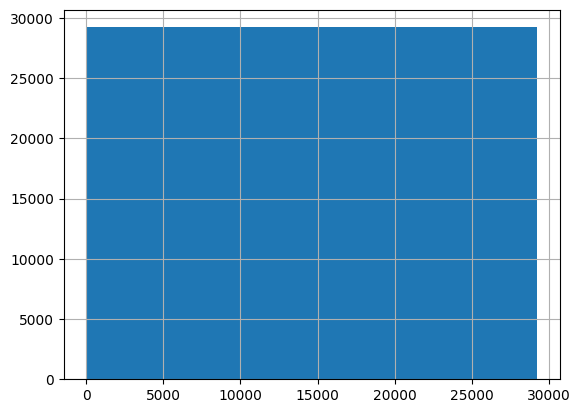

In [32]:
df['pixel_id'].hist()

# Drop unnecessary columns

In [33]:
df.drop(columns=['.geo','constant','system:index','ds_division'], inplace=True)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292290 entries, 0 to 292289
Data columns (total 39 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   B1                 292290 non-null  float64
 1   B11                292290 non-null  float64
 2   B12                292290 non-null  float64
 3   B2                 292290 non-null  float64
 4   B3                 292290 non-null  float64
 5   B4                 292290 non-null  float64
 6   B5                 292290 non-null  float64
 7   B6                 292290 non-null  float64
 8   B7                 292290 non-null  float64
 9   B8                 292290 non-null  float64
 10  B8A                292290 non-null  float64
 11  B9                 292290 non-null  float64
 12  SCL                292290 non-null  float64
 13  cloud_pct          292290 non-null  float64
 14  date               292290 non-null  object 
 15  elevation          292290 non-null  int64  
 16  la

In [35]:
# Calculate counts per pixel
pixel_counts = df.groupby('pixel_id').size().reset_index(name='actual_slots')

# Calculate missing slots
pixel_counts['missing_slots'] = 10 - pixel_counts['actual_slots']

# Filter to see only those with gaps
gaps_df = pixel_counts[pixel_counts['missing_slots'] > 0]

print(f"Total unique pixels: {len(pixel_counts)}")
print(f"Pixels with missing slots: {len(gaps_df)}")
print(gaps_df.head())

Total unique pixels: 29229
Pixels with missing slots: 0
Empty DataFrame
Columns: [pixel_id, actual_slots, missing_slots]
Index: []


# Extracting lan lat and pixel id

In [36]:
import pandas as pd

# --- 1. EXTRACT COORDINATE LOOKUP ---
# Assuming 'df_raw' is your dataframe with 43 columns mentioned above
print("📍 Extracting coordinate lookup table...")

# We only need the unique mapping of pixel_id to its coordinates
coords_lookup = df[['pixel_id', 'lat', 'lon']].drop_duplicates(subset=['pixel_id'])
coords_lookup.info()

📍 Extracting coordinate lookup table...
<class 'pandas.core.frame.DataFrame'>
Index: 29229 entries, 0 to 29228
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_id  29229 non-null  int64  
 1   lat       29229 non-null  float64
 2   lon       29229 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 913.4 KB


In [37]:
coords_lookup.head()

,pixel_id,lat,lon
0,0,7.961319,79.750184
1,22001,8.051152,81.250373
2,6024,9.344724,80.302649
3,22000,8.055643,81.250373
4,21999,8.019711,81.250373


# Save coordinate dataframe

In [38]:
coords_lookup.to_csv("unique_coordinates.csv", index=False)

# Disaster hazard vectorization

In [116]:
# Identify the boolean hazard columns
hazard_cols = [
    'hazard_DROUGHT', 'hazard_FLOOD', 'hazard_HEAVY_RAIN',
    'hazard_LANDSLIDE', 'hazard_LIGHTNING', 'hazard_WIND'
]

# Convert Booleans to Integers (True/False -> 1/0) for the Sigmoid head
df[hazard_cols] = df[hazard_cols].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292290 entries, 0 to 292289
Data columns (total 39 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   B1                 292290 non-null  float64
 1   B11                292290 non-null  float64
 2   B12                292290 non-null  float64
 3   B2                 292290 non-null  float64
 4   B3                 292290 non-null  float64
 5   B4                 292290 non-null  float64
 6   B5                 292290 non-null  float64
 7   B6                 292290 non-null  float64
 8   B7                 292290 non-null  float64
 9   B8                 292290 non-null  float64
 10  B8A                292290 non-null  float64
 11  B9                 292290 non-null  float64
 12  SCL                292290 non-null  float64
 13  cloud_pct          292290 non-null  float64
 14  date               292290 non-null  object 
 15  elevation          292290 non-null  int64  
 16  la

In [117]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
B1,292290.0,NaN,NaN,NaN,3581.109044,2503.895472,144.0,1261.0,3178.0,5442.0,15681.0
B11,292290.0,NaN,NaN,NaN,2599.094011,869.11748,110.0,2004.0,2422.5,3045.0,7903.5
B12,292290.0,NaN,NaN,NaN,2051.727001,761.991634,72.0,1536.0,2029.0,2479.375,6718.5
B2,292290.0,NaN,NaN,NaN,3446.47561,2406.972589,138.0,1208.0,3030.5,5224.5,14983.0
B3,292290.0,NaN,NaN,NaN,3426.043553,2239.386766,222.0,1380.0,2995.5,5061.0,14002.0
B4,292290.0,NaN,NaN,NaN,3293.714,2197.531391,136.0,1381.5,2849.0,4882.5,13901.0
B5,292290.0,NaN,NaN,NaN,3694.997547,2128.982106,273.5,1843.0,3238.5,5193.875,14886.0
B6,292290.0,NaN,NaN,NaN,4225.601743,1837.343012,251.0,2733.0,3813.0,5496.0,14221.0
B7,292290.0,NaN,NaN,NaN,4446.542785,1753.300886,258.0,3085.0,4076.0,5669.5,13998.0
B8,292290.0,NaN,NaN,NaN,4397.319292,1757.20912,220.0,3053.0,4018.0,5585.5,13383.0


In [118]:
df['district'].unique()

array(['Puttalam', 'Polonnaruwa', 'Kilinochchi', 'Trincomalee',
       'Batticaloa', 'Anuradhapura', 'Ampara', 'Ratnapura', 'Vavuniya',
       'Monaragala', 'Galle', 'Kegalle', 'Kurunegala', 'Hambantota',
       'Mullaitivu', 'Jaffna', 'Mannar', 'Kalutara', 'Matara', 'Gampaha',
       'Colombo', nan, 'Matale', 'Kandy', 'Nuwara Eliya', 'Badulla'],
      dtype=object)

In [119]:
# Extract the rows where district is missing
missing_districts = df[df['district'].isna()]

# Display them
print(f"Found {len(missing_districts)} rows with missing districts.")
display(missing_districts)

Found 10 rows with missing districts.


,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,tmean,tmin,pixel_id,district,hazard_FLOOD,hazard_HEAVY_RAIN,hazard_LANDSLIDE,hazard_LIGHTNING,hazard_WIND,hazard_DROUGHT
9250,1361.5,3187.0,2021.5,1561.0,1747.5,1896.0,2294.5,2494.5,2657.5,2639.0,...,28.379627,24.617456,23545,NaN,0,0,0,0,0,0
31918,3415.5,2396.0,2255.0,3372.0,3335.0,3265.5,3383.0,3535.0,3702.5,3737.5,...,27.131426,23.716074,23545,NaN,0,0,0,0,0,0
69978,1587.0,2426.0,2107.0,1655.0,1812.0,1918.0,2325.0,2522.0,2641.0,2622.0,...,27.741102,24.527170,23545,NaN,0,0,0,0,0,0
107786,3135.0,1942.5,1969.0,3337.0,3191.5,3045.5,3296.5,3363.5,3409.0,3406.0,...,25.389925,23.183710,23545,NaN,0,0,0,0,0,0
128726,391.5,219.0,113.5,352.0,410.0,337.0,534.0,557.0,599.5,521.0,...,25.739286,22.755793,23545,NaN,0,0,0,0,0,0
168742,4896.0,1486.5,1476.0,4637.0,4585.0,4424.0,4552.0,4608.0,4654.5,4703.5,...,25.391771,23.059381,23545,NaN,0,0,0,0,0,0
180065,5801.0,1550.0,1821.0,5795.0,5537.0,5320.0,6144.0,5894.0,5640.0,5737.0,...,25.356247,22.602274,23545,NaN,0,0,0,0,0,0
210099,1435.5,1854.0,1467.0,1959.0,2038.5,1905.0,2311.5,2543.0,2634.5,2622.5,...,25.267216,20.584803,23545,NaN,0,0,0,0,0,0
260815,3078.0,3040.0,2826.0,3002.0,2990.0,2895.0,3413.0,3545.0,3636.0,3403.0,...,25.431830,22.514444,23545,NaN,0,0,0,0,0,0
282224,2036.0,2097.0,1789.0,2272.0,2222.0,2059.0,2466.0,2708.0,2794.0,2728.0,...,25.322617,23.176706,23545,NaN,0,0,0,0,0,0


In [120]:
df['district']== 'nan'

0         False
1         False
2         False
3         False
4         False
          ...  
292285    False
292286    False
292287    False
292288    False
292289    False
Name: district, Length: 292290, dtype: bool

# Handle missing values and data cleaning

In [121]:
# Define Column Groups
bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
weather_cols = ['rain_1d', 'rain_3d', 'rain_7d', 'rain_14d', 'rain_30d', 
                    'tmean', 'tmin', 'tmax', 't_day', 't_night', 'rh_mean']
terrain_cols = ['elevation', 'slope']

In [122]:
import pandas as pd
import numpy as np
from scipy.spatial import KDTree

def handle_missing_values(df):
    print("🚀 Starting Refined Production Data Cleaning Pipeline...")

    # --- STEP -0.5: SANITIZE STRINGS ---
    # Convert string-based nulls from GEE to actual Python NaNs
    df = df.replace(['nan', 'NaN', 'None', 'null'], np.nan)

    # --- STEP -1: DISTRICT ENFORCEMENT ---
    initial_count = len(df)
    # Drop rows where district is NaN and reset index
    df = df.dropna(subset=['district']).copy()
    df = df.reset_index(drop=True)
    dropped_districts = initial_count - len(df)
    print(f"📍 Step -1: Dropped {dropped_districts} rows with missing districts. New count: {len(df)}")

    # --- STEP 0: TYPE ENFORCEMENT & HAZARDS ---
    bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
    weather_cols = ['rain_1d', 'rain_3d', 'rain_7d', 'rain_14d', 'rain_30d', 
                    'tmean', 'tmin', 'tmax', 't_day', 't_night', 'rh_mean']
    terrain_cols = ['elevation', 'slope']
    hazard_cols = [c for c in df.columns if c.lower().startswith('hazard')]

    # 1. Fill Hazards with 0 (No event)
    if hazard_cols:
        df[hazard_cols] = df[hazard_cols].fillna(0).astype('int8')
        print(f"🛡️ Step 0: Hazards filled with 0.")

    # 2. Round SCL and Cast (Essential for correct category mapping)
    if 'SCL' in df.columns:
        # Rounding 3.8 to 4 ensures correct classification
        df['SCL'] = pd.to_numeric(df['SCL'], errors='coerce').round().fillna(0).astype('int8')
        print("🏷️ Step 0: SCL rounded and cast to Int8.")

    # 3. Ensure Spectral Bands are Float32
    for col in bands:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')

    # 4. Convert Date to Datetime
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        print("📅 Step 0: Date converted to datetime objects.")

    # --- STEP A-F: SPATIAL/TEMPORAL REPAIR ---
    df = df.sort_values(by=['pixel_id', 'timestep'], ascending=[True, False])

    # Spatial Imputation
    existing_weather = [c for c in weather_cols if c in df.columns]
    if existing_weather:
        for ts in df['timestep'].unique():
            ts_mask = (df['timestep'] == ts)
            for col in existing_weather:
                if df.loc[ts_mask, col].isnull().any():
                    valid = df[ts_mask & df[col].notnull()]
                    missing = df[ts_mask & df[col].isnull()]
                    if not valid.empty:
                        tree = KDTree(valid[['lat', 'lon']].values)
                        _, idx = tree.query(missing[['lat', 'lon']].values)
                        df.loc[missing.index, col] = valid.iloc[idx][col].values

    # Band Interpolation
    df[bands] = df.groupby('pixel_id', group_keys=False)[bands].apply(
        lambda group: group.interpolate(method='linear', limit_direction='both')
    )

    # Weather Temporal Fallback (ffill/bfill within pixels)
    if existing_weather:
        df[existing_weather] = df.groupby('pixel_id')[existing_weather].ffill().bfill()

    # Terrain constant fill
    existing_terrain = [c for c in terrain_cols if c in df.columns]
    if existing_terrain:
        df[existing_terrain] = df.groupby('pixel_id')[existing_terrain].ffill().bfill()

    # --- STEP H: FINAL GLOBAL SAFETY NET ---
    # This catches values for pixels that have NO valid records for a column
    print("🛡️ Step H: Applying Global Median Fallback...")
    final_nulls = df.isnull().sum().sum()
    if final_nulls > 0:
        # Fill numeric columns with their respective global medians
        num_cols = df.select_dtypes(include=[np.number]).columns
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())
        
        # Fill remaining (object/string) with 'Unknown'
        obj_cols = df.select_dtypes(include=['object']).columns
        df[obj_cols] = df[obj_cols].fillna('Unknown')
        
        # Absolute catch-all
        df = df.fillna(0)
    
    print(f"🏁 Cleaning finished. Final NaN count: {df.isnull().sum().sum()}")
    return df

# Execute the pipeline
df = handle_missing_values(df)

# Verify with your yearly count request
print("\n--- Rows per Year ---")
print(df.groupby(df['date'].dt.year).size())

print("\n--- Final Data Types ---")
df.info()

🚀 Starting Refined Production Data Cleaning Pipeline...
📍 Step -1: Dropped 10 rows with missing districts. New count: 292280
🛡️ Step 0: Hazards filled with 0.
🏷️ Step 0: SCL rounded and cast to Int8.
📅 Step 0: Date converted to datetime objects.
🛡️ Step H: Applying Global Median Fallback...
🏁 Cleaning finished. Final NaN count: 0

--- Rows per Year ---
date
2025    175368
2026    116912
dtype: int64

--- Final Data Types ---
<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 0 to 292279
Data columns (total 39 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   B1                 292280 non-null  float32       
 1   B11                292280 non-null  float32       
 2   B12                292280 non-null  float32       
 3   B2                 292280 non-null  float32       
 4   B3                 292280 non-null  float32       
 5   B4                 292280 non-null  float32       
 6   B5          

In [123]:
df.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,tmean,tmin,pixel_id,district,hazard_FLOOD,hazard_HEAVY_RAIN,hazard_LANDSLIDE,hazard_LIGHTNING,hazard_WIND,hazard_DROUGHT
0,605.0,3114.0,2207.0,806.0,1066.0,1265.0,1687.0,2379.0,2776.0,2766.0,...,27.704155,25.003885,0,Puttalam,0,0,0,0,0,0
56856,2014.5,2080.0,1882.0,2004.5,2159.5,2132.5,2356.0,2960.5,3197.5,3214.5,...,26.613668,24.635828,0,Puttalam,0,0,0,0,0,0
82380,3508.0,2921.5,2453.5,4177.0,3945.0,3637.0,3841.5,4049.0,4102.0,4185.5,...,27.029259,24.498270,0,Puttalam,0,0,0,0,0,0
88138,4754.0,2187.0,1606.0,4312.0,4199.0,4054.0,3875.0,4172.0,4308.0,4328.0,...,25.573345,22.863337,0,Puttalam,0,0,0,0,0,0
142207,397.0,1842.5,1173.5,432.0,671.0,645.0,1123.0,1924.0,2210.0,2156.5,...,25.762974,22.858606,0,Puttalam,0,0,0,0,0,0


In [124]:
df.info( )

<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 0 to 292279
Data columns (total 39 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   B1                 292280 non-null  float32       
 1   B11                292280 non-null  float32       
 2   B12                292280 non-null  float32       
 3   B2                 292280 non-null  float32       
 4   B3                 292280 non-null  float32       
 5   B4                 292280 non-null  float32       
 6   B5                 292280 non-null  float32       
 7   B6                 292280 non-null  float32       
 8   B7                 292280 non-null  float32       
 9   B8                 292280 non-null  float32       
 10  B8A                292280 non-null  float32       
 11  B9                 292280 non-null  float32       
 12  SCL                292280 non-null  int8          
 13  cloud_pct          292280 non-null  float64      

# EDA

In [125]:
for col in df.columns:
    print(col)
    print(df[col].unique())

B1
[  605.   2014.5  3508.  ... 10700.  12493.   8566.5]
B11
[3114.  2080.  2921.5 ... 1144.5  534.   487. ]
B12
[2207.  1882.  2453.5 ...  333.  4155.5  626.5]
B2
[  806.   2004.5  4177.  ... 10775.   8637.5 12277. ]
B3
[ 1066.   2159.5  3945.  ...  8924.   8004.5 11479. ]
B4
[ 1265.   2132.5  3637.  ...   249.  11064.    389.5]
B5
[1687.  2356.  3841.5 ...  678.   727.   747.5]
B6
[2379.  2960.5 4049.  ... 1172.  1384.5  884. ]
B7
[2776.  3197.5 4102.  ... 1233.5 1137.  1114.5]
B8
[2766.  3214.5 4185.5 ... 1344.  1045.   987.5]
B8A
[3091.  3380.5 4120.5 ... 1671.5 1443.5  957. ]
B9
[3389.  2564.  5504.  ... 1620.5 1622.5  457. ]
SCL
[ 5  6  9  8  4  7 10  3]
cloud_pct
[40.64093976 87.68420206 60.35375953 87.16447406 44.34302628 59.26496621
 72.62084556 39.07837033 53.53536017 66.6720273 ]
date
<DatetimeArray>
['2025-10-15 00:00:00', '2025-10-30 00:00:00', '2025-11-14 00:00:00',
 '2025-11-29 00:00:00', '2025-12-14 00:00:00', '2025-12-29 00:00:00',
 '2026-01-13 00:00:00', '2026-01-28 0

In [126]:
# 1. Convert 'date' to datetime objects
# 'errors=coerce' handles any weird formatting by turning them into NaT (Not a Time)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Group by the year and count
# Using .size() is usually faster if you just want the total row count per year
yearly_counts = df.groupby(df['date'].dt.year).size()

# Or use .count() if you want to see counts for every individual column
# yearly_counts = df.groupby(df['date'].dt.year).count()

print(yearly_counts)

date
2025    175368
2026    116912
dtype: int64


In [127]:
print(df["date"].dtype)
print(df["date"].min(), df["date"].max())

datetime64[ns]
2025-10-15 00:00:00 2026-02-27 00:00:00


In [128]:
df.groupby(df['date'].dt.year).count()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,tmean,tmin,pixel_id,district,hazard_FLOOD,hazard_HEAVY_RAIN,hazard_LANDSLIDE,hazard_LIGHTNING,hazard_WIND,hazard_DROUGHT
date,,,,,,,,,,,,,,,,,,,,,
2025,175368,175368,175368,175368,175368,175368,175368,175368,175368,175368,...,175368,175368,175368,175368,175368,175368,175368,175368,175368,175368
2026,116912,116912,116912,116912,116912,116912,116912,116912,116912,116912,...,116912,116912,116912,116912,116912,116912,116912,116912,116912,116912


# Visualizing the timesteps

In [129]:
# 1. Get the list of available timesteps for each pixel
available_timesteps = df.groupby('pixel_id')['timestep'].apply(list).reset_index()

# 2. Count how many slots are available vs missing
# Target is 10 timesteps per pixel
available_timesteps['slot_count'] = available_timesteps['timestep'].apply(len)
available_timesteps['missing_slots'] = 10 - available_timesteps['slot_count']

# 3. Identify the specific missing timestep indices
# Assuming timesteps should be from 0 to 9
all_slots = set(range(10))
available_timesteps['missing_indices'] = available_timesteps['timestep'].apply(
    lambda x: list(all_slots - set(x))
)

print(available_timesteps.head())

   pixel_id                         timestep  slot_count  missing_slots  \
0         0  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   
1         1  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   
2         2  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   
3         3  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   
4         4  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   

  missing_indices  
0             [0]  
1             [0]  
2             [0]  
3             [0]  
4             [0]  


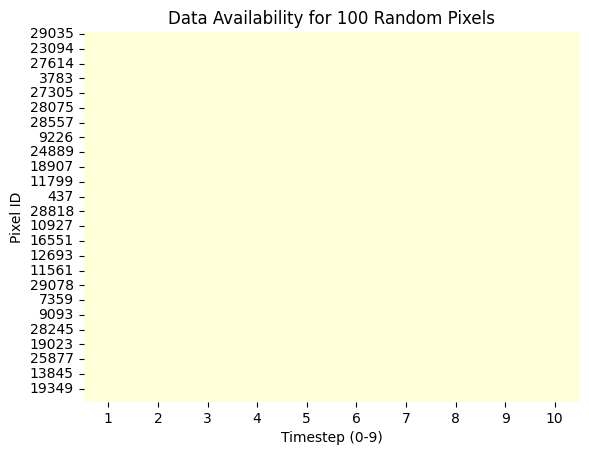

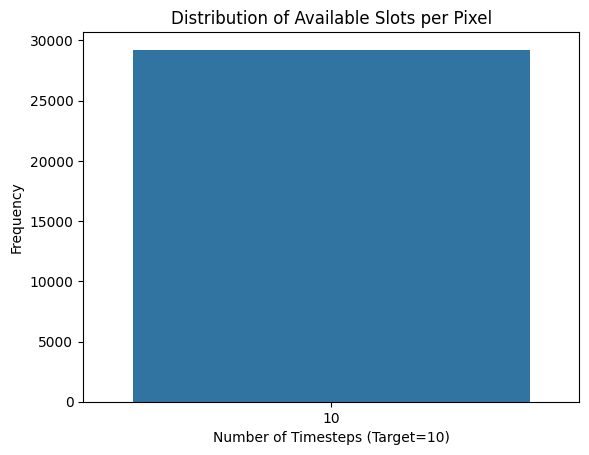

In [130]:
# Create a pivot table for the heatmap
# Fill with 1 where data exists, 0 otherwise
pivot_df = df.pivot_table(index='pixel_id', columns='timestep', values='B1', aggfunc='count').fillna(0)

# If you have too many pixels, you can sample them for the visualization
sample_size = min(100, len(pivot_df))
sns.heatmap(pivot_df.sample(sample_size), cbar=False, cmap="YlGnBu")

plt.title(f'Data Availability for {sample_size} Random Pixels')
plt.xlabel('Timestep (0-9)')
plt.ylabel('Pixel ID')
plt.show()

# 4. Distribution of counts
sns.countplot(data=available_timesteps, x='slot_count')
plt.title('Distribution of Available Slots per Pixel')
plt.xlabel('Number of Timesteps (Target=10)')
plt.ylabel('Frequency')
plt.show()

<Axes: >

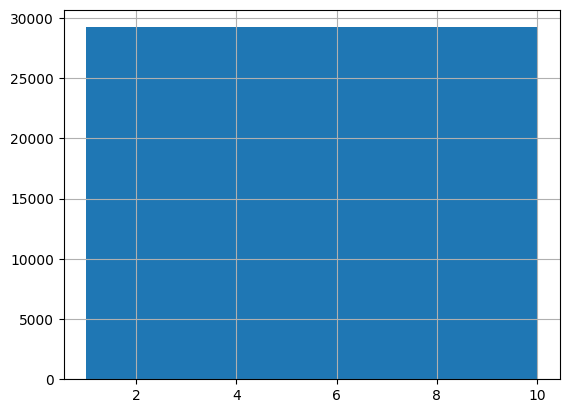

In [131]:
df['timestep'].hist()

In [132]:
df['pixel_id'].value_counts()

pixel_id
29228    10
0        10
1        10
2        10
3        10
         ..
16       10
15       10
14       10
13       10
12       10
Name: count, Length: 29228, dtype: int64

# **Extract date, year, month, month_day**

In [133]:
full_dataset = df

In [134]:
full_dataset["date"] = pd.to_datetime(full_dataset["date"], format="%Y-%m-%d")

full_dataset['year'] = full_dataset['date'].dt.year
# Extract month number (1–12)
full_dataset['month'] = full_dataset['date'].dt.month
full_dataset['day'] = full_dataset['date'].dt.day

# Extract month and day as MM-DD format
full_dataset['month_day'] = full_dataset['date'].dt.strftime('%m-%d')

In [135]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 0 to 292279
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   B1                 292280 non-null  float32       
 1   B11                292280 non-null  float32       
 2   B12                292280 non-null  float32       
 3   B2                 292280 non-null  float32       
 4   B3                 292280 non-null  float32       
 5   B4                 292280 non-null  float32       
 6   B5                 292280 non-null  float32       
 7   B6                 292280 non-null  float32       
 8   B7                 292280 non-null  float32       
 9   B8                 292280 non-null  float32       
 10  B8A                292280 non-null  float32       
 11  B9                 292280 non-null  float32       
 12  SCL                292280 non-null  int8          
 13  cloud_pct          292280 non-null  float64      

In [136]:
full_dataset.groupby(full_dataset['date'].dt.year).count()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,hazard_FLOOD,hazard_HEAVY_RAIN,hazard_LANDSLIDE,hazard_LIGHTNING,hazard_WIND,hazard_DROUGHT,year,month,day,month_day
date,,,,,,,,,,,,,,,,,,,,,
2025,175368,175368,175368,175368,175368,175368,175368,175368,175368,175368,...,175368,175368,175368,175368,175368,175368,175368,175368,175368,175368
2026,116912,116912,116912,116912,116912,116912,116912,116912,116912,116912,...,116912,116912,116912,116912,116912,116912,116912,116912,116912,116912


In [137]:
year_counts = full_dataset['year'].value_counts().sort_index()
print(year_counts)

year
2025    175368
2026    116912
Name: count, dtype: int64


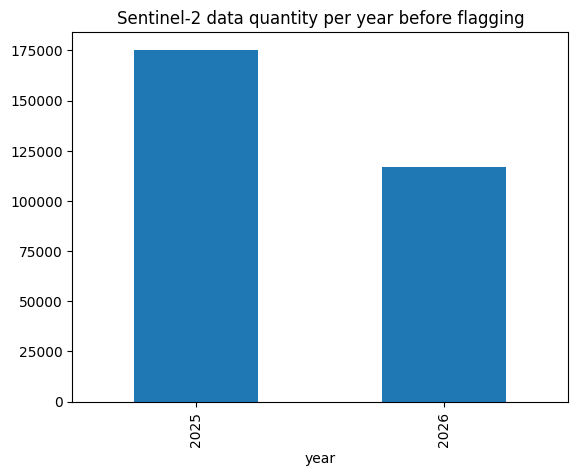

In [138]:
ax = year_counts.plot(kind='bar')
plt.title("Sentinel-2 data quantity per year before flagging")

fig = ax.get_figure()   # extract the Figure from the Axes
fig.savefig("sentinel2yearly_before_flagging.png", dpi=300, bbox_inches='tight')

plt.show()

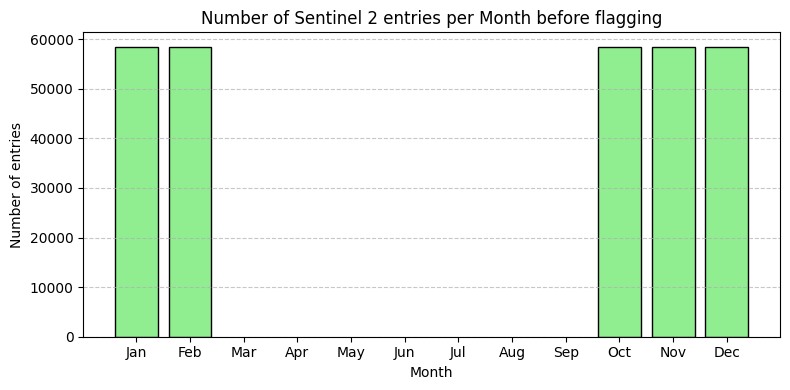

In [139]:
plt.figure(figsize=(8,4))
month_counts = full_dataset['month'].value_counts().sort_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.bar(month_counts.index, month_counts.values, color='lightgreen', edgecolor='black')
plt.xticks(ticks=range(1,13), labels=month_labels)
plt.title('Number of Sentinel 2 entries per Month before flagging')
plt.xlabel('Month')
plt.ylabel('Number of entries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

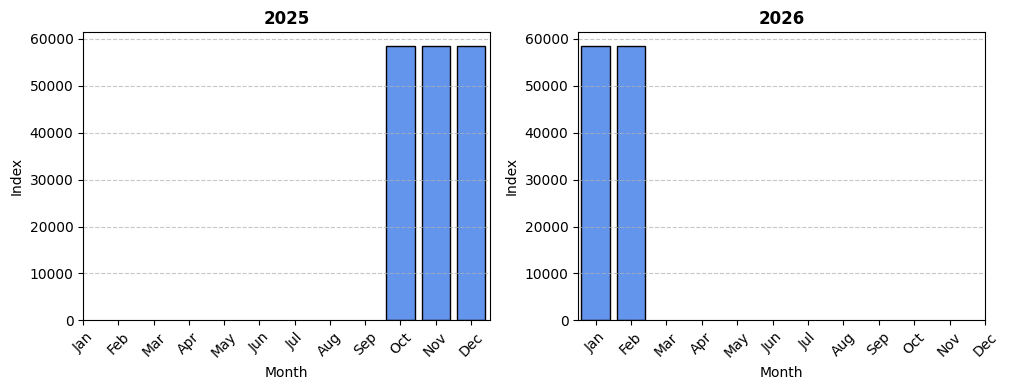

In [140]:
# Unique years sorted
years = sorted(full_dataset['year'].unique())
n_years = len(years)

# Compute grid size for subplots
cols = 3   # you can change to 2 or 4 depending on your preference
rows = math.ceil(n_years / cols)

# Prepare figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()  # flatten in case of 2D grid
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Plot each year
for i, year in enumerate(years):
    ax = axes[i]
    year_df = full_dataset[full_dataset['year'] == year]
    month_counts = year_df['month'].value_counts().sort_index()
    
    ax.bar(month_counts.index, month_counts.values, color='cornflowerblue', edgecolor='black')
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_labels, rotation=45)
    ax.set_title(f'{year}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Index')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide empty subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()
fig.savefig("plot1.png", dpi=300, bbox_inches='tight')

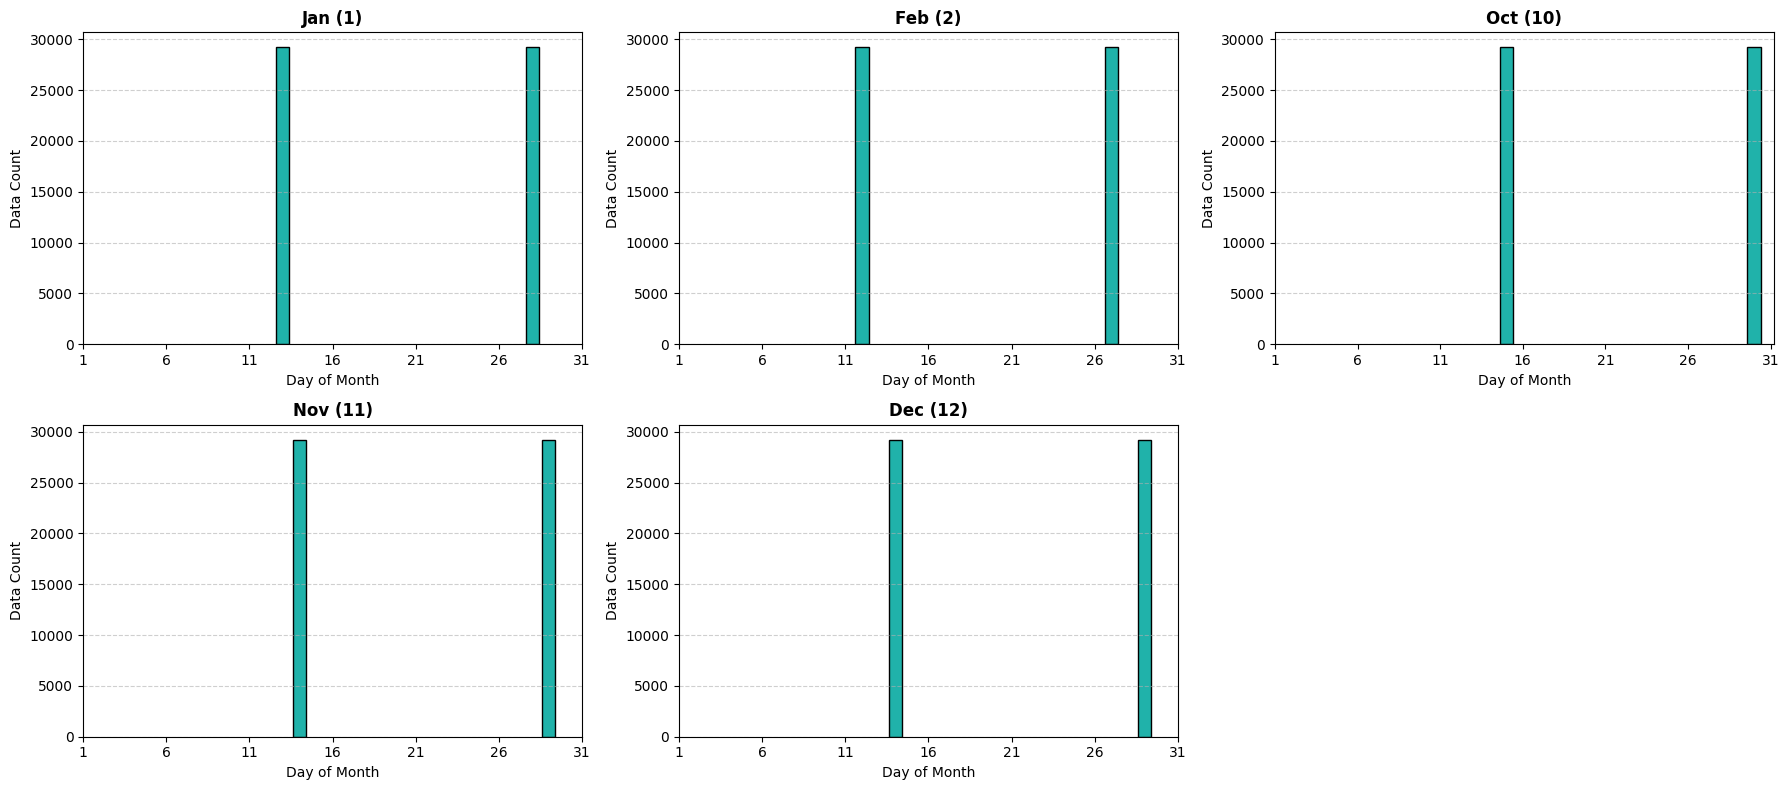

In [141]:
# -----------------------------
# Plot distribution per month
# -----------------------------
months = sorted(full_dataset['month'].dropna().unique())
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

cols = 3
rows = math.ceil(len(months) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, month in enumerate(months):
    ax = axes[i]
    month_df = full_dataset[full_dataset['month'] == month]
    day_counts = month_df['day'].value_counts().sort_index()
    
    ax.bar(day_counts.index, day_counts.values, color='lightseagreen', edgecolor='black')
    ax.set_title(f'{month_labels[month-1]} ({month})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Day of Month')
    ax.set_ylabel('Data Count')
    ax.set_xticks(range(1, 32, 5))
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
fig.savefig("plot2.png", dpi=300, bbox_inches='tight')

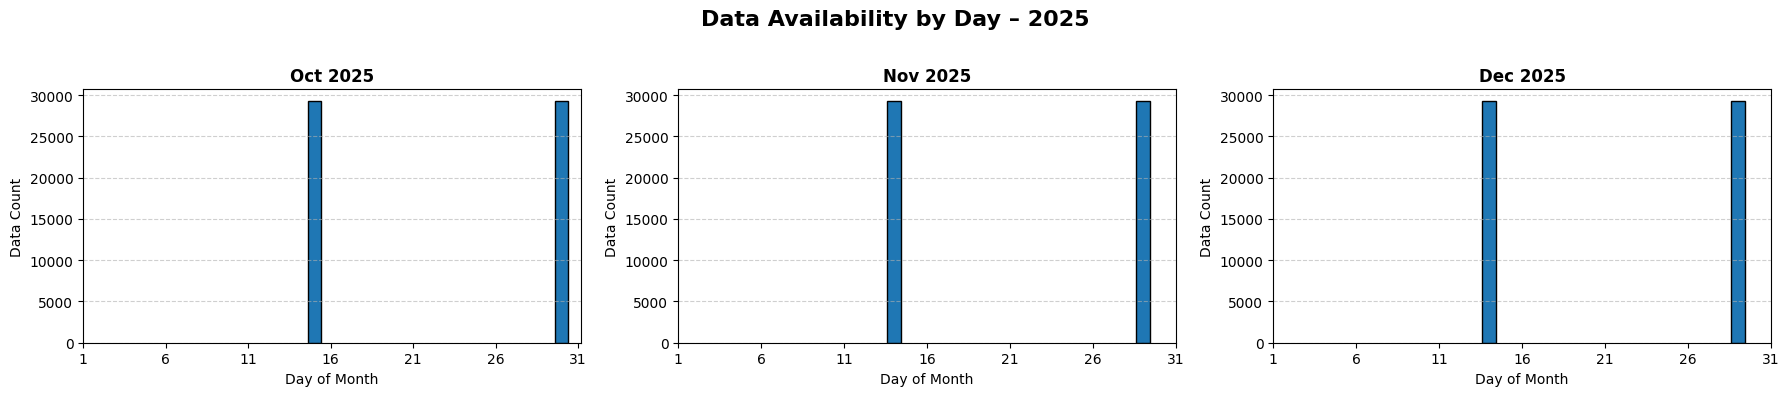

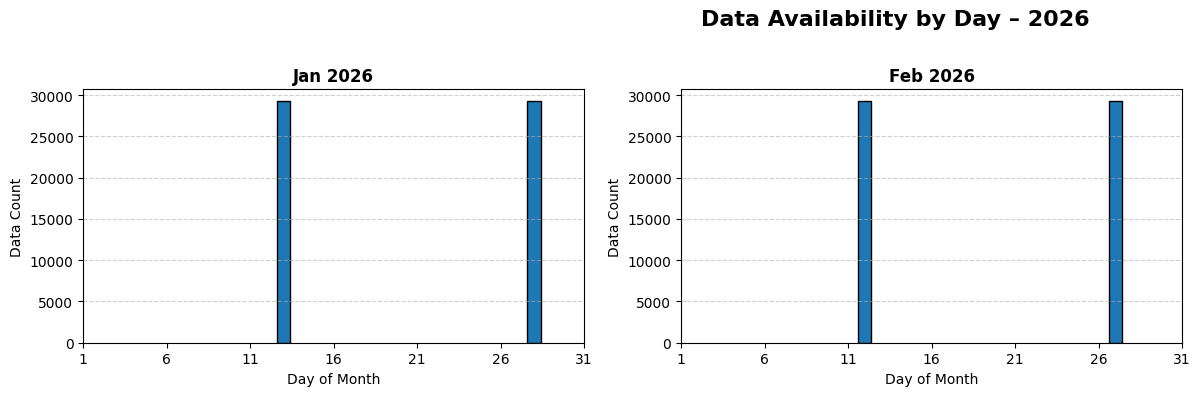

In [142]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

years = sorted(full_dataset['year'].dropna().unique())

for year in years:
    year_df = full_dataset[full_dataset['year'] == year]
    months = sorted(year_df['month'].dropna().unique())

    cols = 3
    rows = math.ceil(len(months) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten()

    for i, month in enumerate(months):
        ax = axes[i]
        month_df = year_df[year_df['month'] == month]
        day_counts = month_df['day'].value_counts().sort_index()

        ax.bar(day_counts.index, day_counts.values,
               edgecolor='black')
        ax.set_title(f'{month_labels[month-1]} {year}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Day of Month')
        ax.set_ylabel('Data Count')
        ax.set_xticks(range(1, 32, 5))
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Data Availability by Day – {year}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Save figure
    fig.savefig(f"plot_monthly_distribution_{year}_before_flagging.png",
                dpi=300, bbox_inches='tight')


In [143]:
full_dataset['date'].unique()

<DatetimeArray>
['2025-10-15 00:00:00', '2025-10-30 00:00:00', '2025-11-14 00:00:00',
 '2025-11-29 00:00:00', '2025-12-14 00:00:00', '2025-12-29 00:00:00',
 '2026-01-13 00:00:00', '2026-01-28 00:00:00', '2026-02-12 00:00:00',
 '2026-02-27 00:00:00']
Length: 10, dtype: datetime64[ns]

# Scatter plot of all the points

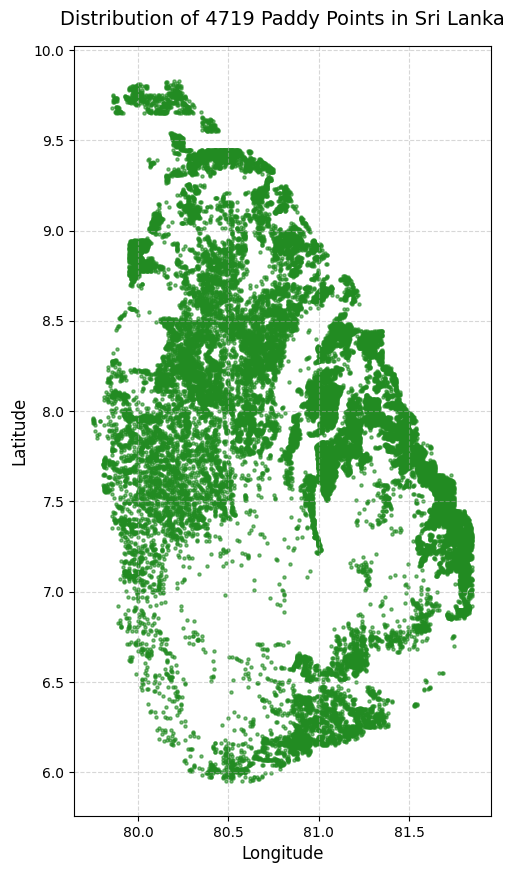

In [144]:
# 1. Extract only the unique geographical points
# We drop duplicates based on 'pixel_id' to get the ~4,719 unique locations
unique_points = full_dataset.drop_duplicates(subset=['pixel_id'])

# 2. Set up the plot dimensions (Taller than it is wide, like Sri Lanka)
plt.figure(figsize=(7, 10))

# 3. Create the scatter plot
# lon is X (horizontal), lat is Y (vertical)
plt.scatter(
    unique_points['lon'], 
    unique_points['lat'], 
    color='forestgreen',  # Green for paddy fields
    alpha=0.6,            # Slight transparency to see point density
    s=5                   # Small point size
)

# 4. Add labels and styling
plt.title('Distribution of 4719 Paddy Points in Sri Lanka', fontsize=14, pad=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Add a subtle grid to help read coordinates
plt.grid(True, linestyle='--', alpha=0.5)

# Ensure the aspect ratio is equal so the map isn't distorted
plt.gca().set_aspect('equal', adjustable='box')

# 5. Show the plot
plt.show()

In [145]:
len(unique_points)

29228

In [146]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 0 to 292279
Data columns (total 43 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   B1                 292280 non-null  float32       
 1   B11                292280 non-null  float32       
 2   B12                292280 non-null  float32       
 3   B2                 292280 non-null  float32       
 4   B3                 292280 non-null  float32       
 5   B4                 292280 non-null  float32       
 6   B5                 292280 non-null  float32       
 7   B6                 292280 non-null  float32       
 8   B7                 292280 non-null  float32       
 9   B8                 292280 non-null  float32       
 10  B8A                292280 non-null  float32       
 11  B9                 292280 non-null  float32       
 12  SCL                292280 non-null  int8          
 13  cloud_pct          292280 non-null  float64      

# Rescaling and masking uncleaned pixels

In [147]:
bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
full_dataset[bands] = full_dataset[bands].astype('float32') / 10000.0
    
# B. Define Strictly Clean Mask
# SCL 4=Veg, 5=Non-Veg, 6=Water, 7=Unclassified
clean_mask = (full_dataset['SCL'].astype(float).round().isin([4, 5, 6, 7])) & (full_dataset['cloud_pct'] <= 50)

# C. "Erase" bad data (Setting to NaN for the Imputation step)
full_dataset.loc[~clean_mask, bands] = np.nan
full_dataset['is_clean'] = clean_mask

In [148]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 0 to 292279
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   B1                 50395 non-null   float32       
 1   B11                50395 non-null   float32       
 2   B12                50395 non-null   float32       
 3   B2                 50395 non-null   float32       
 4   B3                 50395 non-null   float32       
 5   B4                 50395 non-null   float32       
 6   B5                 50395 non-null   float32       
 7   B6                 50395 non-null   float32       
 8   B7                 50395 non-null   float32       
 9   B8                 50395 non-null   float32       
 10  B8A                50395 non-null   float32       
 11  B9                 50395 non-null   float32       
 12  SCL                292280 non-null  int8          
 13  cloud_pct          292280 non-null  float64      

In [149]:
df['SCL'].unique()

array([ 5,  6,  9,  8,  4,  7, 10,  3], dtype=int8)

# Filling nans

In [150]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

def prepare_dataset_for_bilstm(df):
    print("--- 🚀 Starting Spectral-Only Imputation Process ---")
    
    # 1. INITIAL CLEANUP: SCL Formatting
    if 'SCL' in df.columns:
        print("  > Formatting SCL category values for masking...")
        df['SCL'] = pd.to_numeric(df['SCL'], errors='coerce').round()
    
    # 2. DEFINE TARGET BANDS VS WEATHER
    # We explicitly define the spectral bands to be cleaned.
    spectral_bands = [
        'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12'
    ]
    # Filter only for bands that exist in your specific dataframe
    target_cols = [c for c in spectral_bands if c in df.columns]
    
    # Identify weather columns for verification print
    weather_keywords = ['rain', 'tmean', 'tmax', 'tmin', 'rh_mean', 't_day', 't_night']
    all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    weather_found = [c for c in all_numeric if any(k in c.lower() for k in weather_keywords)]
    
    print(f"  > Target bands to be imputed: {target_cols}")
    print(f"  > Weather columns to be preserved (untouched): {weather_found}")

    # 3. MASKING: Identify clean pixels
    valid_classes = [4, 5, 6, 7] # Vegetation, Soil, Water, Unclassified
    df["is_clean"] = (df["cloud_pct"] <= 50) & (df["SCL"].isin(valid_classes))
    
    clean_count = df["is_clean"].sum()
    print(f"  > Cloud-free data found: {clean_count} rows ({clean_count/len(df)*100:.2f}%)")

    # Initialize the filled dataframe
    df_filled = df.copy()
    
    # CRITICAL CHANGE: Only set target spectral bands to NaN in cloudy rows.
    # Weather columns (CHIRPS/ERA5) will keep their original values.
    print(f"  > Masking {len(target_cols)} spectral bands in cloudy rows...")
    df_filled.loc[~df_filled["is_clean"], target_cols] = np.nan
    
    # --- STEP 1: SPATIAL INTERPOLATION ---
    print(f"\n[Step 1/3] Spatial Interpolation (Nearest Neighbor) for {len(target_cols)} bands...")
    def spatial_fill(group):
        clean = group['is_clean']
        if clean.any() and (~clean).any():
            coords_c = group.loc[clean, ['lat', 'lon']].values
            vals_c = group.loc[clean, target_cols].values
            coords_d = group.loc[~clean, ['lat', 'lon']].values
            
            tree = cKDTree(coords_c)
            _, idx = tree.query(coords_d, k=1)
            group.loc[~clean, target_cols] = vals_c[idx]
        return group
    
    nan_before_spatial = df_filled[target_cols].isna().sum().sum()
    df_filled = df_filled.groupby('timestep', group_keys=False).apply(spatial_fill)
    nan_after_spatial = df_filled[target_cols].isna().sum().sum()
    print(f"  > Spatial fill fixed {nan_before_spatial - nan_after_spatial} band values.")

    # --- STEP 2: TEMPORAL INTERPOLATION ---
    print("[Step 2/3] Temporal Interpolation (Linear) for remaining gaps...")
    def temporal_fill(group):
        group = group.sort_values('timestep')
        subset = group[target_cols].copy()
        if subset.isna().any().any():
            subset = subset.interpolate(method='linear', limit_direction='both')
            group[target_cols] = subset
        return group
    
    df_filled = df_filled.groupby('pixel_id', group_keys=False).apply(temporal_fill)
    final_nan_count = df_filled[target_cols].isna().sum().sum()
    print(f"  > Temporal fill complete. Remaining NaNs in bands: {final_nan_count}")

    # --- STEP 3: FALLBACK & FINAL ROUNDING ---
    print("\n[Step 3/3] Finalizing Data & SCL Cleanup...")
    
    # Fallback only for spectral bands that were cloudy for the entire year
    if final_nan_count > 0:
        print(f"  > Applying global mean fallback for {final_nan_count} persistent band gaps.")
        column_means = df.loc[df["is_clean"], target_cols].mean().fillna(0)
        df_filled[target_cols] = df_filled[target_cols].fillna(column_means)

    if 'SCL' in df_filled.columns:
        df_filled['SCL'] = df_filled['SCL'].round().clip(4, 7).astype(int)

    # Verification: Ensure weather columns didn't gain any NaNs from our masking
    weather_nans = df_filled[weather_found].isna().sum().sum()
    print(f"  > Verification: Weather columns have {weather_nans} NaNs (should be 0 or unchanged).")

    print("--- ✅ Process Complete: Spectral bands filled, Weather preserved ---")
    return df_filled

df = prepare_dataset_for_bilstm(full_dataset)
df.info()

--- 🚀 Starting Spectral-Only Imputation Process ---
  > Formatting SCL category values for masking...
  > Target bands to be imputed: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']
  > Weather columns to be preserved (untouched): ['rain_14d', 'rain_1d', 'rain_30d', 'rain_3d', 'rain_7d', 'rh_mean', 't_day', 't_night', 'tmax', 'tmean', 'tmin', 'hazard_HEAVY_RAIN']
  > Cloud-free data found: 50395 rows (17.24%)
  > Masking 12 spectral bands in cloudy rows...

[Step 1/3] Spatial Interpolation (Nearest Neighbor) for 12 bands...


/tmp/ipykernel_55/408145159.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filled = df_filled.groupby('timestep', group_keys=False).apply(spatial_fill)


  > Spatial fill fixed 447468 band values.
[Step 2/3] Temporal Interpolation (Linear) for remaining gaps...
  > Temporal fill complete. Remaining NaNs in bands: 0

[Step 3/3] Finalizing Data & SCL Cleanup...
  > Verification: Weather columns have 0 NaNs (should be 0 or unchanged).
--- ✅ Process Complete: Spectral bands filled, Weather preserved ---
<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 263337 to 27628
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   B1                 292280 non-null  float32       
 1   B11                292280 non-null  float32       
 2   B12                292280 non-null  float32       
 3   B2                 292280 non-null  float32       
 4   B3                 292280 non-null  float32       
 5   B4                 292280 non-null  float32       
 6   B5                 292280 non-null  float32       
 7   B6                 292280 non-

/tmp/ipykernel_55/408145159.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filled = df_filled.groupby('pixel_id', group_keys=False).apply(temporal_fill)


In [151]:
df.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,hazard_HEAVY_RAIN,hazard_LANDSLIDE,hazard_LIGHTNING,hazard_WIND,hazard_DROUGHT,year,month,day,month_day,is_clean
263337,0.849150,0.454500,0.338500,0.807500,0.75095,0.712600,0.775050,0.777000,0.762750,0.732500,...,0,0,0,0,0,2026,2,27,02-27,False
248264,0.849150,0.454500,0.338500,0.807500,0.75095,0.712600,0.775050,0.777000,0.762750,0.732500,...,0,0,0,0,0,2026,2,12,02-12,False
220271,0.849150,0.454500,0.338500,0.807500,0.75095,0.712600,0.775050,0.777000,0.762750,0.732500,...,0,0,0,0,0,2026,1,28,01-28,True
178959,0.579333,0.364417,0.264783,0.552733,0.52300,0.496567,0.554133,0.582133,0.582167,0.560217,...,0,0,0,0,0,2026,1,13,01-13,False
174265,0.309517,0.274333,0.191067,0.297967,0.29505,0.280533,0.333217,0.387267,0.401583,0.387933,...,0,0,0,0,0,2025,12,29,12-29,False


In [152]:
df['is_clean']

263337    False
248264    False
220271     True
178959    False
174265    False
          ...  
118448     True
88149     False
82434     False
57231     False
27628      True
Name: is_clean, Length: 292280, dtype: bool

In [153]:
df['SCL'].unique

<bound method Series.unique of 263337    7
248264    7
220271    6
178959    7
174265    6
         ..
118448    4
88149     7
82434     5
57231     7
27628     5
Name: SCL, Length: 292280, dtype: int64>

<Axes: >

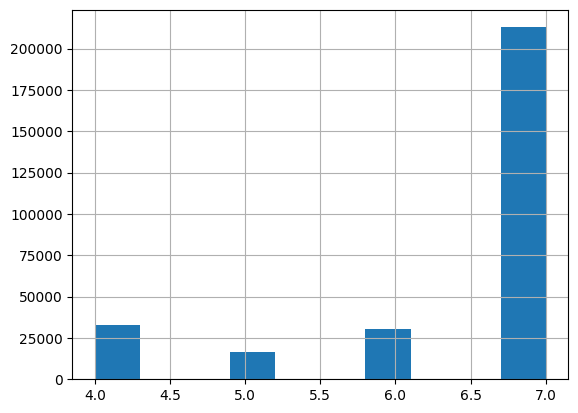

In [154]:
df['SCL'].hist()

# Feature engineering

In [155]:
def engineer_features(df, eps=1e-6, scale_factor=10000.0):
    """
    Compute vegetation and spectral indices from Sentinel-2 bands safely.
    Automatically scales reflectance, prevents division errors, and clips
    indices to physically meaningful ranges.
    """
    # ---------------------------------------------------------------
    # 2️⃣ Compute all derived indices with safe division and clipping
    # ---------------------------------------------------------------
    df['NDVI']  = np.clip((df['B8'] - df['B4']) / (df['B8'] + df['B4'] + eps), -1, 1)
    df['GLI']   = np.clip((2*df['B3'] - df['B4'] - df['B2']) / (2*df['B3'] + df['B4'] + df['B2'] + eps), -1, 1)
    df['CVI']   = np.clip((df['B8'] * df['B4']) / (df['B3']**2 + eps), 0, 30)
    df['SIPI']  = np.clip((df['B8'] - df['B2']) / (df['B8'] - df['B4'] + eps), 0, 2)
    df['S2REP'] = np.clip(705 + 35 * (((df['B7'] + df['B4'])/2 - df['B5']) / (df['B6'] - df['B5'] + eps)), 680, 750)
    df['CCCI']  = np.clip(((df['B8'] - df['B5'])*(df['B8'] + df['B4'])) / (((df['B8'] + df['B5'])*(df['B8'] - df['B4'])) + eps), 0, 2)
    df['RENDVI']= np.clip((df['B6'] - df['B5']) / (df['B6'] + df['B5'] + eps), -1, 1)
    df['RECI']  = np.clip((df['B8'] / (df['B5'] + eps)) - 1.0, 0, 10)
    df['EVI']   = np.clip((2.5 * (df['B8'] - df['B4'])) / (df['B8'] + 6*df['B4'] - 7.5*df['B2'] + 1 + eps), -1, 1)
    df['EVI2']  = np.clip(2.4 * (df['B8'] - df['B4']) / (df['B8'] + df['B4'] + 1 + eps), -1, 1)
    df['NDWI']  = np.clip((df['B4'] - df['B2']) / (df['B4'] + df['B2'] + eps), -1, 1)
    df['NPCRI'] = np.clip((df['B3'] - df['B8']) / (df['B3'] + df['B8'] + eps), -1, 1)
    df['LSWI']  = np.clip((df['B8'] - df['B11']) / (df['B8'] + df['B11'] + eps), -1, 1)
    df['GCI']   = np.clip((df['B8'] / (df['B3'] + eps)) - 1.0, 0, 10)
    
    df['BSI']   = np.clip((df['B11'] + df['B4'] - df['B8'] - df['B2']) / (df['B11'] + df['B4'] + df['B8'] + df['B2'] + eps), -1, 1)
    df['NDSMI'] = np.clip((df['B8'] - df['B11']) / (df['B8'] + df['B11'] + eps), -1, 1)

    return df
df = engineer_features(df, eps=1e-6, scale_factor=10000.0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 263337 to 27628
Data columns (total 60 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   B1                 292280 non-null  float32       
 1   B11                292280 non-null  float32       
 2   B12                292280 non-null  float32       
 3   B2                 292280 non-null  float32       
 4   B3                 292280 non-null  float32       
 5   B4                 292280 non-null  float32       
 6   B5                 292280 non-null  float32       
 7   B6                 292280 non-null  float32       
 8   B7                 292280 non-null  float32       
 9   B8                 292280 non-null  float32       
 10  B8A                292280 non-null  float32       
 11  B9                 292280 non-null  float32       
 12  SCL                292280 non-null  int64         
 13  cloud_pct          292280 non-null  float64  

# Aggregating median,mean, first and time features

In [156]:
import pandas as pd
import numpy as np

def process_pipeline_for_inference(df):
    print("📦 Starting 10-day Aggregation (Preserving Hazards as int64)...")
    
    # --- 1. PREPARE TEMPORAL BINS ---
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['ten_day'] = df['date'].dt.to_period('10D')
    
    # --- 2. DEFINE COLUMN GROUPS ---
    spectral_indices = [
        'NDVI','EVI','EVI2','LSWI','NDWI','GLI','GCI','CVI',
        'SIPI','RENDVI','RECI','CCCI','S2REP','BSI','NPCRI','NDSMI'
    ]
    
    raw_bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
    
    env_cols = [
        'rain_1d','rain_3d','rain_7d','rain_14d','rain_30d',
        'tmean','tmax','tmin','t_day','t_night','rh_mean'
    ]
    
    # Explicitly list hazard columns (adjust case if necessary to match your df)
    hazard_cols = [
        'hazard_DROUGHT', 'hazard_FLOOD', 'hazard_HEAVY_RAIN', 
        'hazard_LANDSLIDE', 'hazard_LIGHTNING', 'hazard_WIND'
    ]
    
    static_meta = ['lat', 'lon', 'elevation', 'slope', 'pixel_id', 'district']
    meta_mean = ['cloud_pct']
    meta_first = ['SCL', 'date', 'year', 'month', 'month_day', 'timestep']

    # --- 3. BUILD AGGREGATION DICTIONARY ---
    agg_dict = {}
    
    for col in (spectral_indices + raw_bands):
        if col in df.columns: agg_dict[col] = 'median'
            
    for col in (env_cols + meta_mean):
        if col in df.columns: agg_dict[col] = 'mean'
            
    # Use MAX for hazards: If hazard=1 on any day in the 10-day window, result is 1
    for col in hazard_cols:
        if col in df.columns:
            agg_dict[col] = 'max'
            
    for col in (static_meta + meta_first):
        if col in df.columns: agg_dict[col] = 'first' 

    # --- 4. EXECUTE AGGREGATION ---
    df_agg = df.groupby(['pixel_id', 'ten_day'], as_index=False).agg(agg_dict)
    
    df_agg['ten_day_start'] = df_agg['ten_day'].dt.start_time
    df_agg = df_agg.sort_values(['pixel_id', 'ten_day_start'])

    # --- 5. TIME FEATURE ENGINEERING ---
    df_agg["delta_days"] = df_agg.groupby("pixel_id")["ten_day_start"].diff().dt.days.fillna(10)
    df_agg['doy'] = df_agg['ten_day_start'].dt.dayofyear
    df_agg['doy_sin'] = np.sin(2 * np.pi * df_agg['doy'] / 365.25)
    df_agg['doy_cos'] = np.cos(2 * np.pi * df_agg['doy'] / 365.25)

    # --- 6. RENAMING (Only Suffixing Indices and Weather) ---
    # Hazards and Static Meta are NOT renamed
    rename_map = {col: f"{col}_median" for col in spectral_indices if col in df_agg.columns}
    rename_map.update({col: f"{col}_mean" for col in env_cols if col in df_agg.columns})
    
    df_agg = df_agg.rename(columns=rename_map)

    # --- 7. CLEANUP & FINAL TYPE CASTING ---
    df_agg = df_agg.drop(columns=['ten_day'])
    
    # Force hazards back to int64 as requested
    for col in hazard_cols:
        if col in df_agg.columns:
            df_agg[col] = df_agg[col].fillna(0).astype('int64')
    
    print(f"✅ Aggregation complete. Hazards preserved as int64.")
    return df_agg

# Execute
df_inference = process_pipeline_for_inference(df)

📦 Starting 10-day Aggregation (Preserving Hazards as int64)...
✅ Aggregation complete. Hazards preserved as int64.


In [157]:
df = df_inference

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 63 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   NDVI_median        292280 non-null  float32       
 1   EVI_median         292280 non-null  float32       
 2   EVI2_median        292280 non-null  float32       
 3   LSWI_median        292280 non-null  float32       
 4   NDWI_median        292280 non-null  float32       
 5   GLI_median         292280 non-null  float32       
 6   GCI_median         292280 non-null  float32       
 7   CVI_median         292280 non-null  float32       
 8   SIPI_median        292280 non-null  float32       
 9   RENDVI_median      292280 non-null  float32       
 10  RECI_median        292280 non-null  float32       
 11  CCCI_median        292280 non-null  float32       
 12  S2REP_median       292280 non-null  float32       
 13  BSI_median         292280 non-null  float32 

In [159]:
df.head()

,NDVI_median,EVI_median,EVI2_median,LSWI_median,NDWI_median,GLI_median,GCI_median,CVI_median,SIPI_median,RENDVI_median,...,date,year,month,month_day,timestep,ten_day_start,delta_days,doy,doy_sin,doy_cos
0,0.372363,0.262211,0.256746,-0.059184,0.221631,0.014513,1.594723,3.078861,1.305787,0.170191,...,2025-10-15,2025,10,10-15,10,2025-10-15,10.0,288,-0.970882,0.239557
1,0.403806,0.269856,0.262955,-0.033735,0.218106,0.029811,1.702091,3.100575,1.264353,0.188717,...,2025-10-30,2025,10,10-30,9,2025-10-30,15.0,303,-0.877609,0.479378
2,0.440906,0.277931,0.269449,-0.003442,0.213467,0.049230,1.833877,3.115745,1.223062,0.209897,...,2025-11-14,2025,11,11-14,8,2025-11-14,15.0,318,-0.726225,0.687457
3,0.485343,0.286474,0.276248,0.033227,0.207090,0.074694,1.999474,3.116863,1.181916,0.234345,...,2025-11-29,2025,11,11-29,7,2025-11-29,15.0,333,-0.526755,0.850017
4,0.539531,0.295526,0.283373,0.078519,0.197770,0.109549,2.213812,3.088643,1.140912,0.262881,...,2025-12-14,2025,12,12-14,6,2025-12-14,15.0,348,-0.292406,0.956294


In [160]:
df[['ten_day_start','date']]

,ten_day_start,date
0,2025-10-15,2025-10-15
1,2025-10-30,2025-10-30
2,2025-11-14,2025-11-14
3,2025-11-29,2025-11-29
4,2025-12-14,2025-12-14
...,...,...
292275,2025-12-29,2025-12-29
292276,2026-01-13,2026-01-13
292277,2026-01-28,2026-01-28
292278,2026-02-12,2026-02-12


In [161]:
hazard_cols = [
        'hazard_DROUGHT', 'hazard_FLOOD', 'hazard_HEAVY_RAIN', 
        'hazard_LANDSLIDE', 'hazard_LIGHTNING', 'hazard_WIND'
    ]
df[hazard_cols]

,hazard_DROUGHT,hazard_FLOOD,hazard_HEAVY_RAIN,hazard_LANDSLIDE,hazard_LIGHTNING,hazard_WIND
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
292275,0,0,0,0,0,0
292276,0,0,0,0,0,0
292277,0,0,0,0,0,0
292278,0,0,0,0,0,0


📈 Generating plots for 2025...


/tmp/ipykernel_55/3780906281.py:54: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


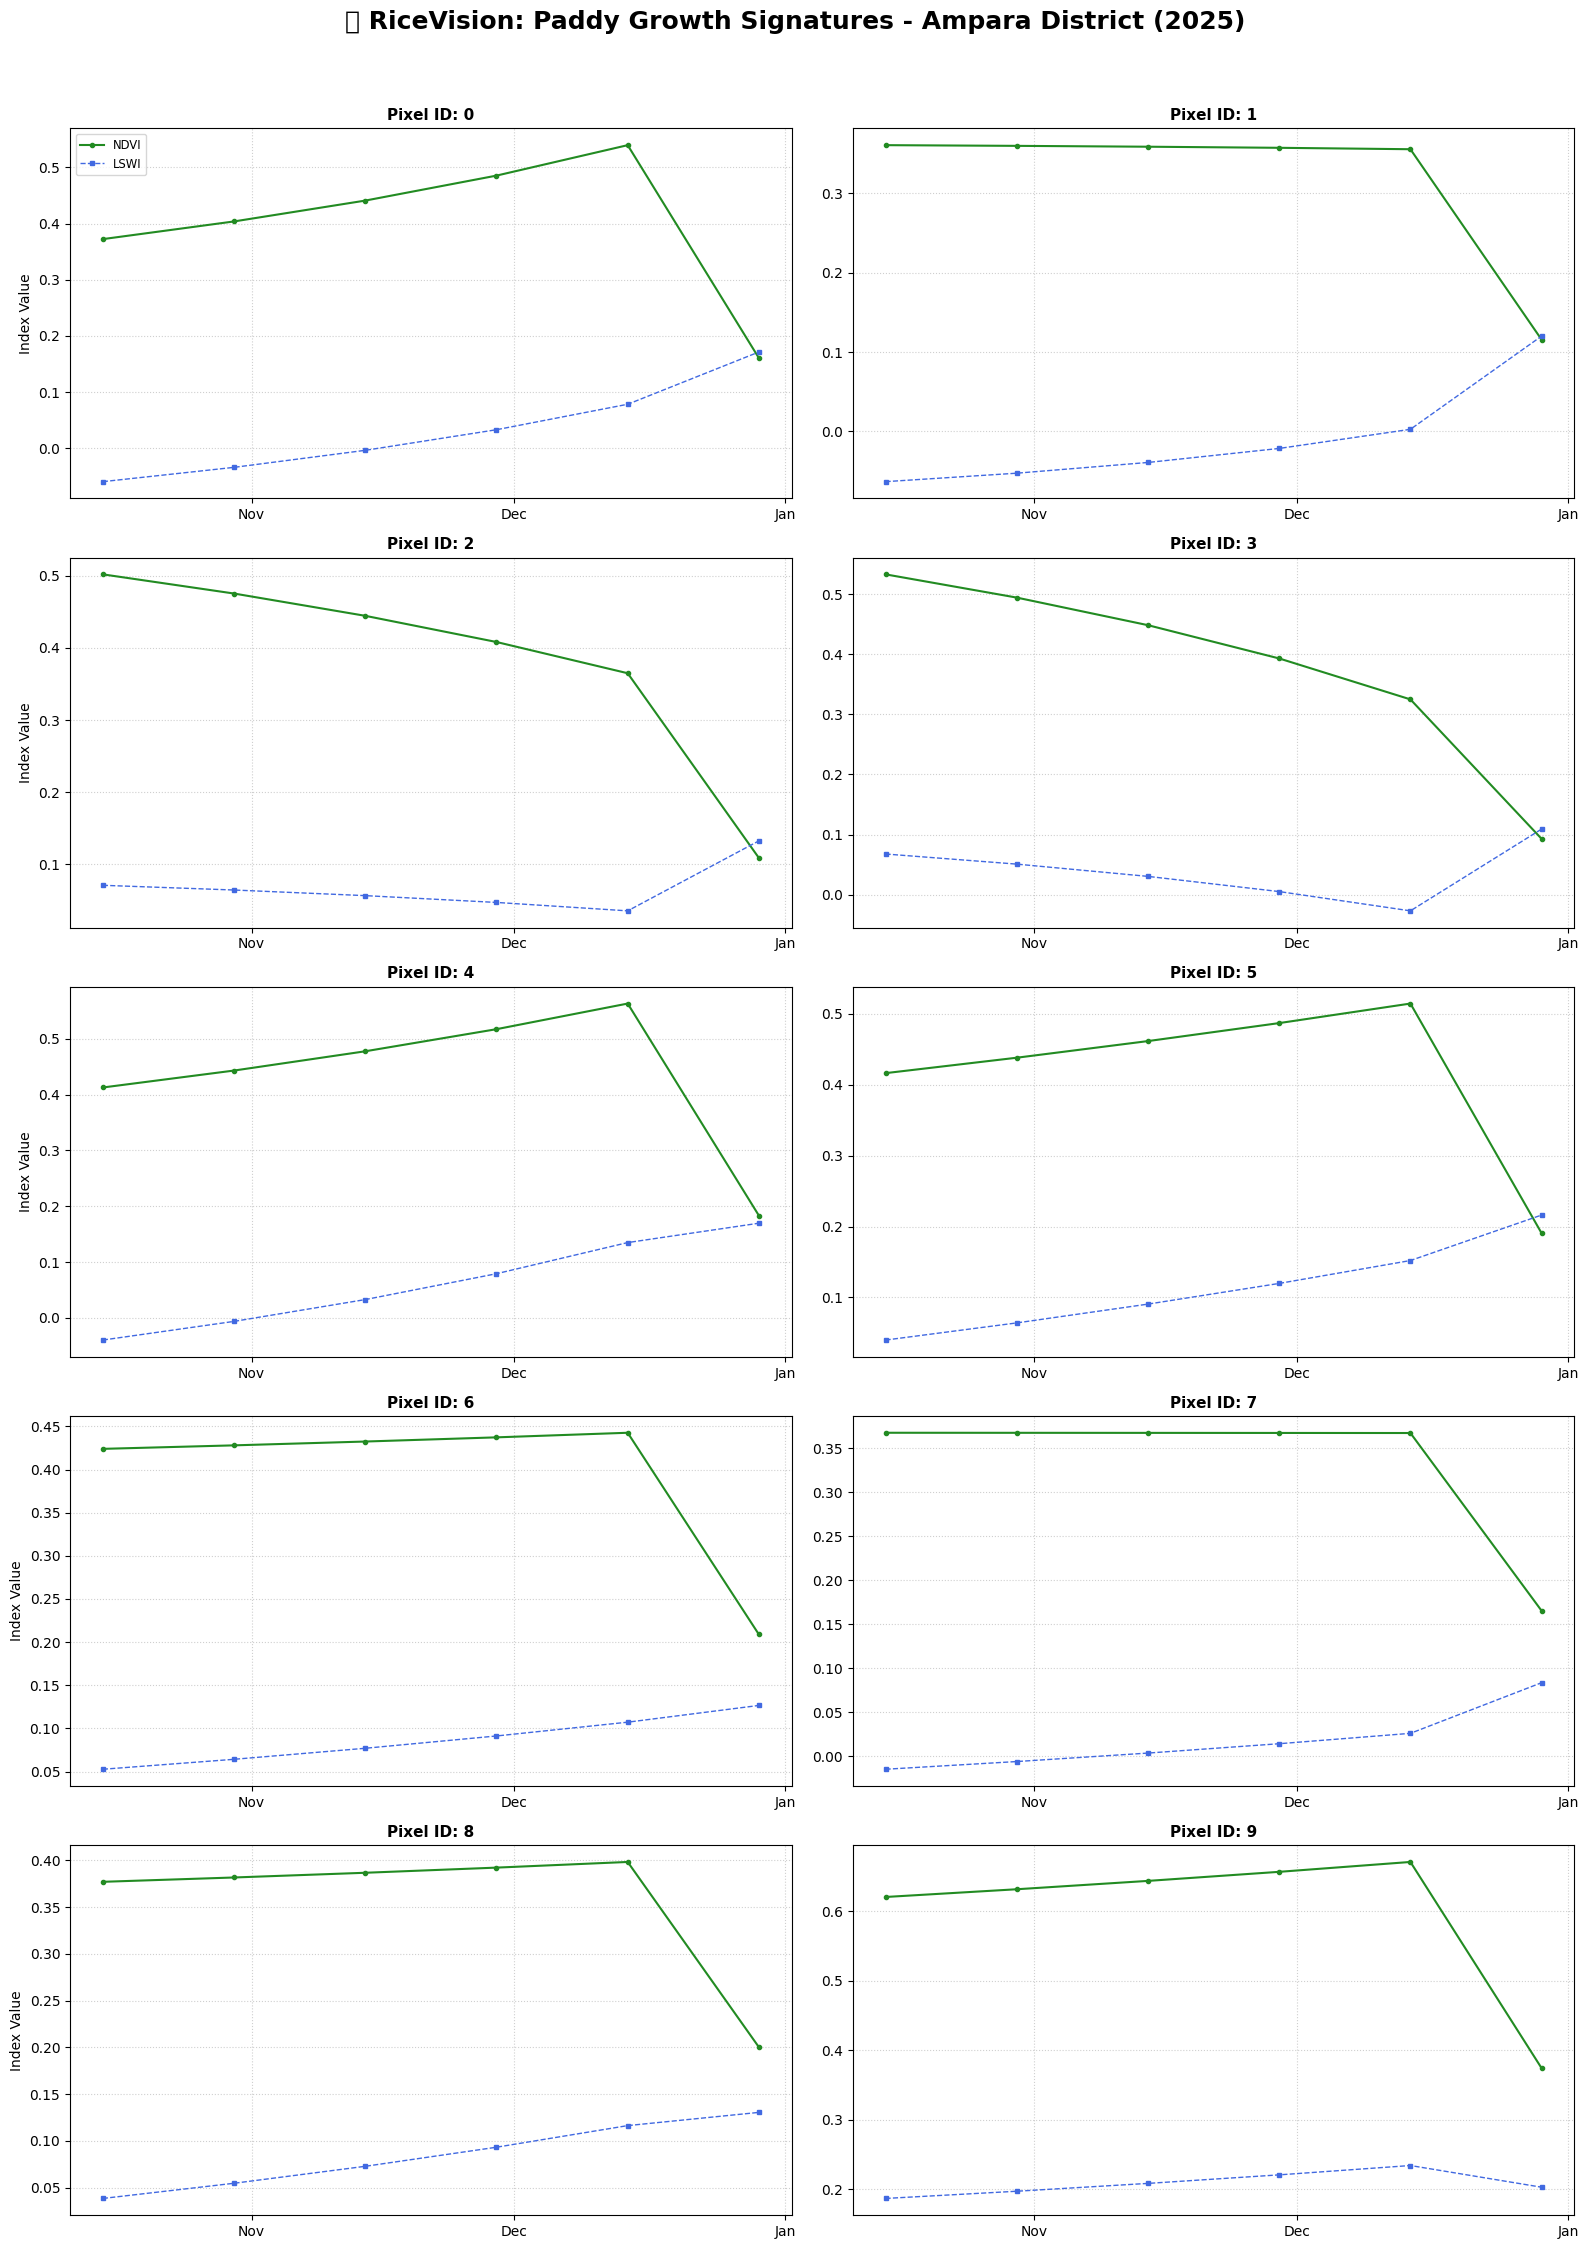

📈 Generating plots for 2026...


/tmp/ipykernel_55/3780906281.py:54: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


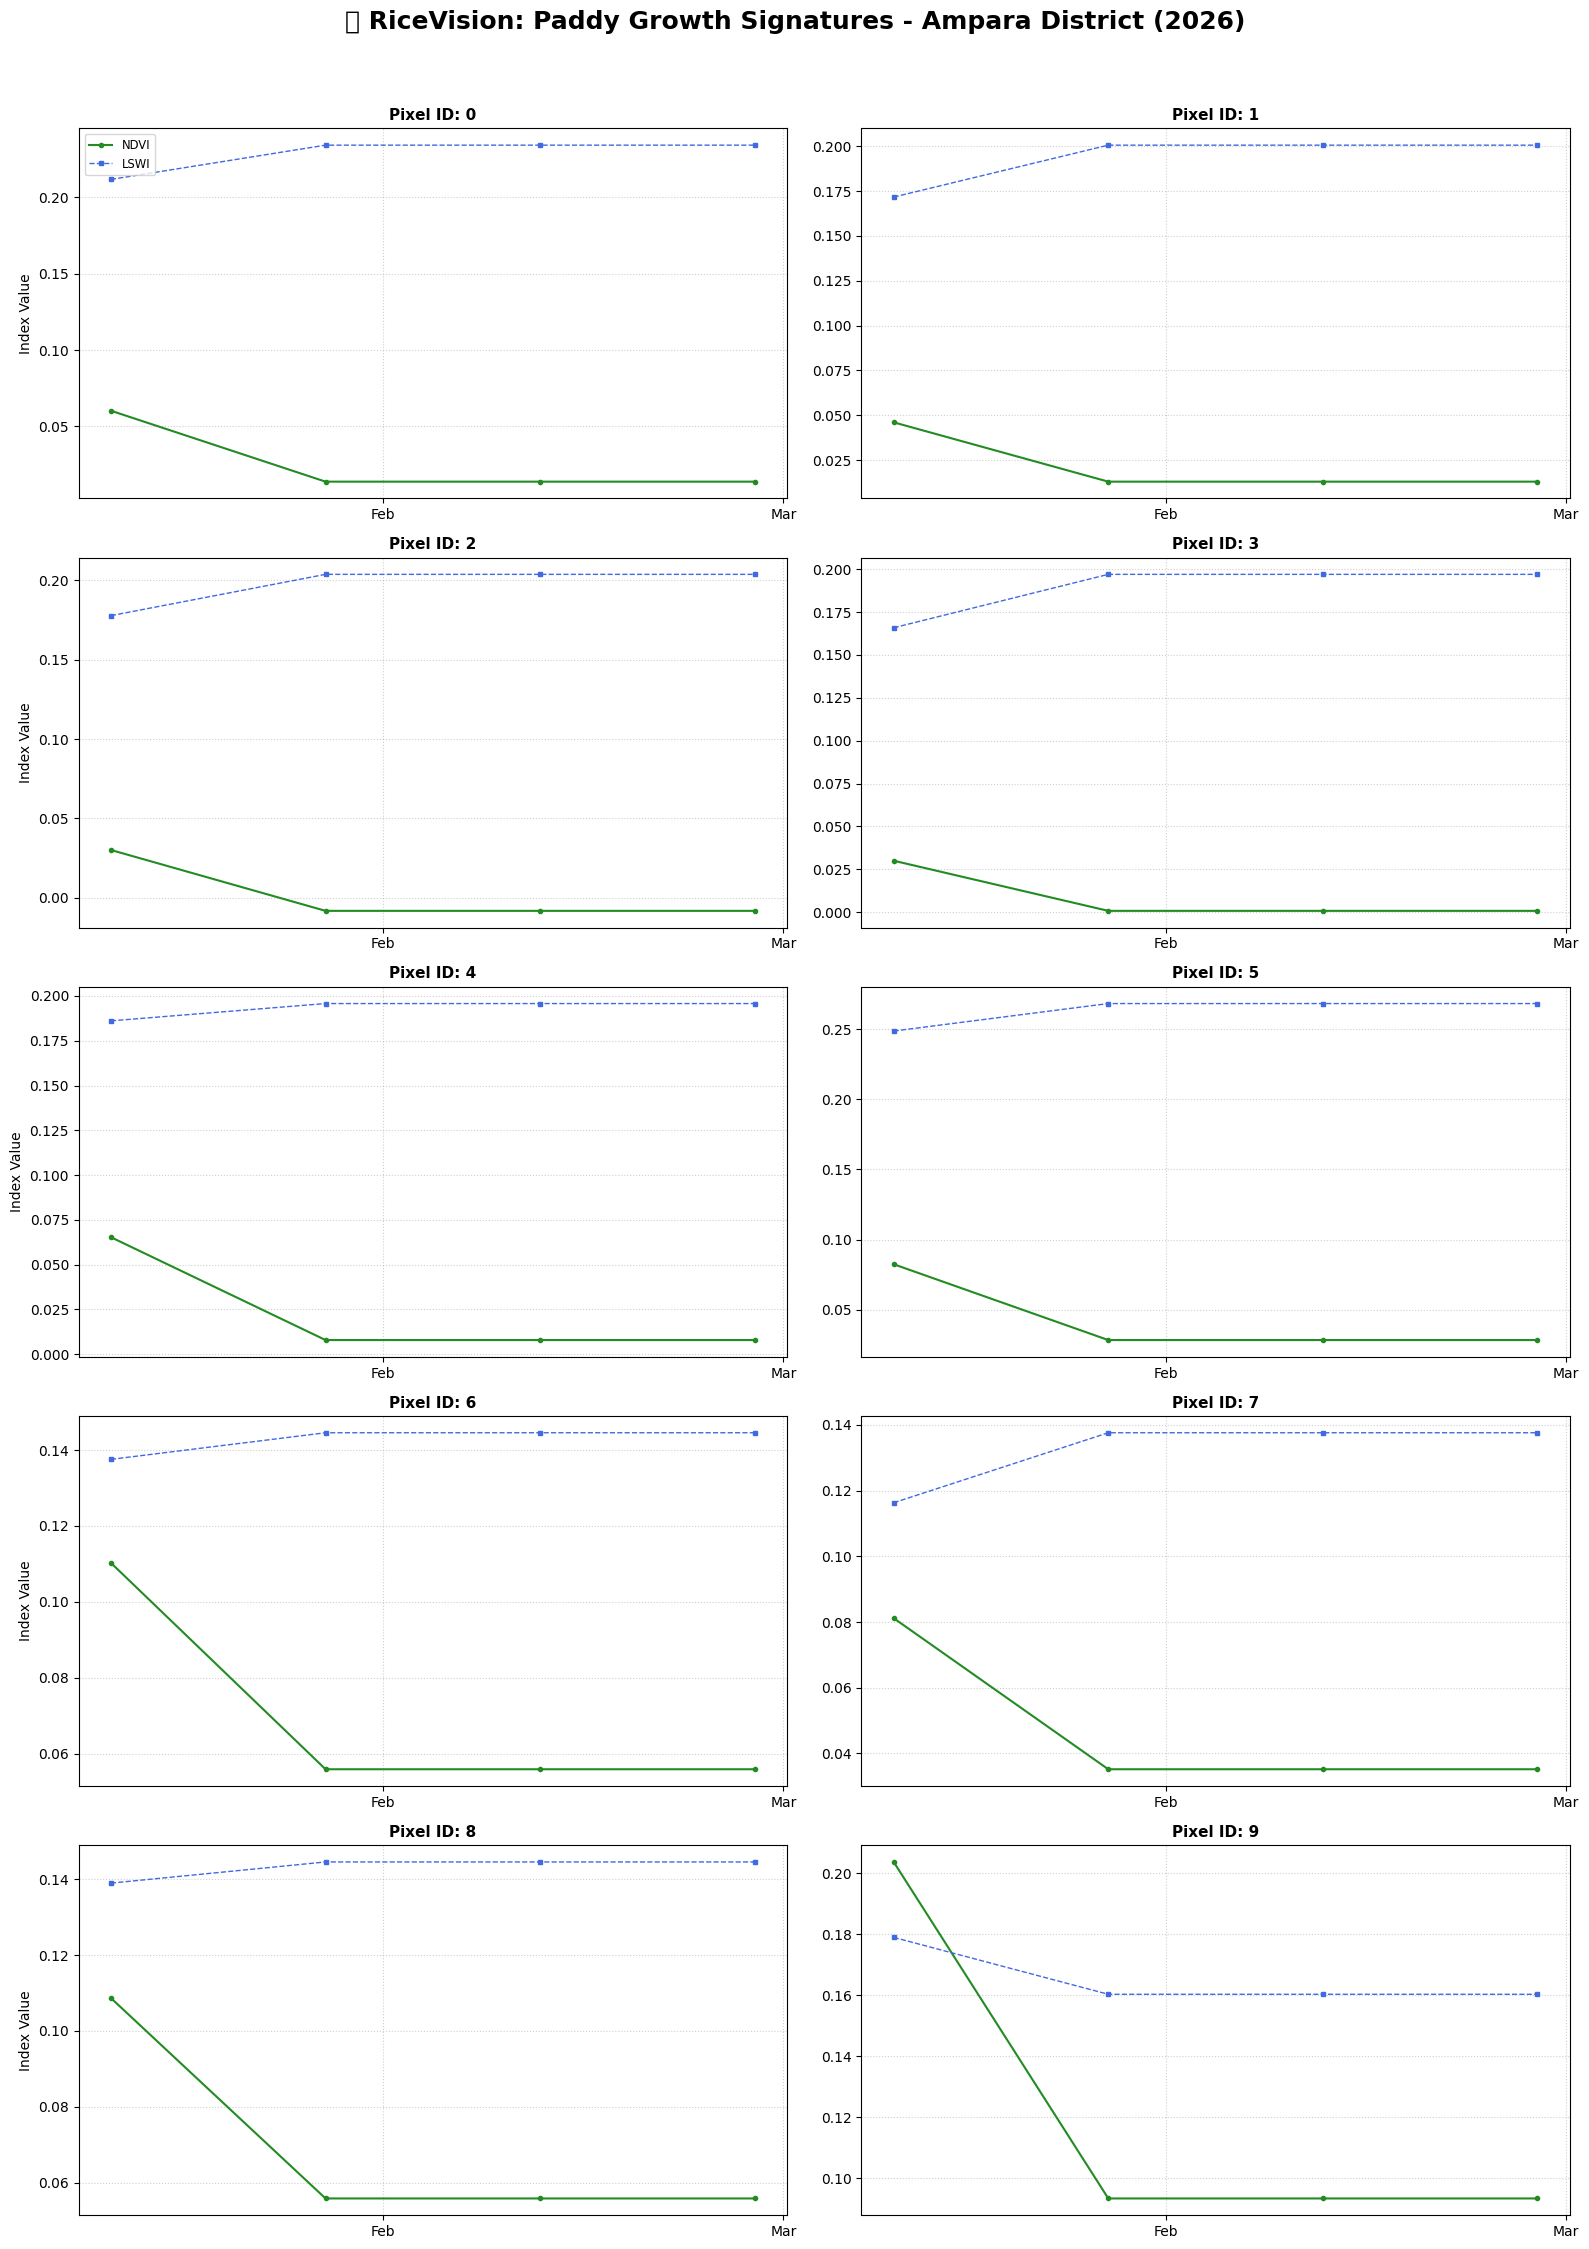

In [162]:
# --- Configuration ---
years_to_plot = [2025, 2026]
pixels_per_year = 10

for year in years_to_plot:
    # 1. Filter data for the specific year
    df_year = df[df['year'] == year].copy()
    
    if df_year.empty:
        print(f"⚠️ No data found for year {year}. Skipping...")
        continue
    
    # 2. Select 10 unique pixel IDs to visualize
    unique_pixels = df_year['pixel_id'].unique()[:pixels_per_year]
    
    # 3. Initialize a 5x2 grid for this year
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 22))
    axes = axes.flatten()  # Flatten for easy iteration
    
    print(f"📈 Generating plots for {year}...")

    for i, pixel_id in enumerate(unique_pixels):
        ax = axes[i]
        
        # Filter and prepare data for the specific pixel
        df_pixel = df_year[df_year['pixel_id'] == pixel_id].copy()
        
        # Convert Period to Timestamp and Sort
        df_pixel['plot_date'] = df_pixel['ten_day_start']
        df_pixel = df_pixel.sort_values('plot_date')
        
        # Plot NDVI and LSWI
        ax.plot(df_pixel['plot_date'], df_pixel['NDVI_median'], 
                label='NDVI', color='forestgreen', marker='o', markersize=3, linewidth=1.5)
        ax.plot(df_pixel['plot_date'], df_pixel['LSWI_median'], 
                label='LSWI', color='royalblue', marker='s', markersize=3, linestyle='--', linewidth=1)
        
        # --- CLEAN X-AXIS ---
        # Show month names only (e.g., Jan, Feb) to save space
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        
        # Styling
        ax.set_title(f"Pixel ID: {pixel_id}", fontsize=11, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        if i % 2 == 0: ax.set_ylabel("Index Value")
        
        # Only show legend on the first plot to reduce clutter
        if i == 0:
            ax.legend(loc='upper left', fontsize='small', frameon=True)

    plt.suptitle(f"🌾 RiceVision: Paddy Growth Signatures - Ampara District ({year})", 
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55/688272659.py:35: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


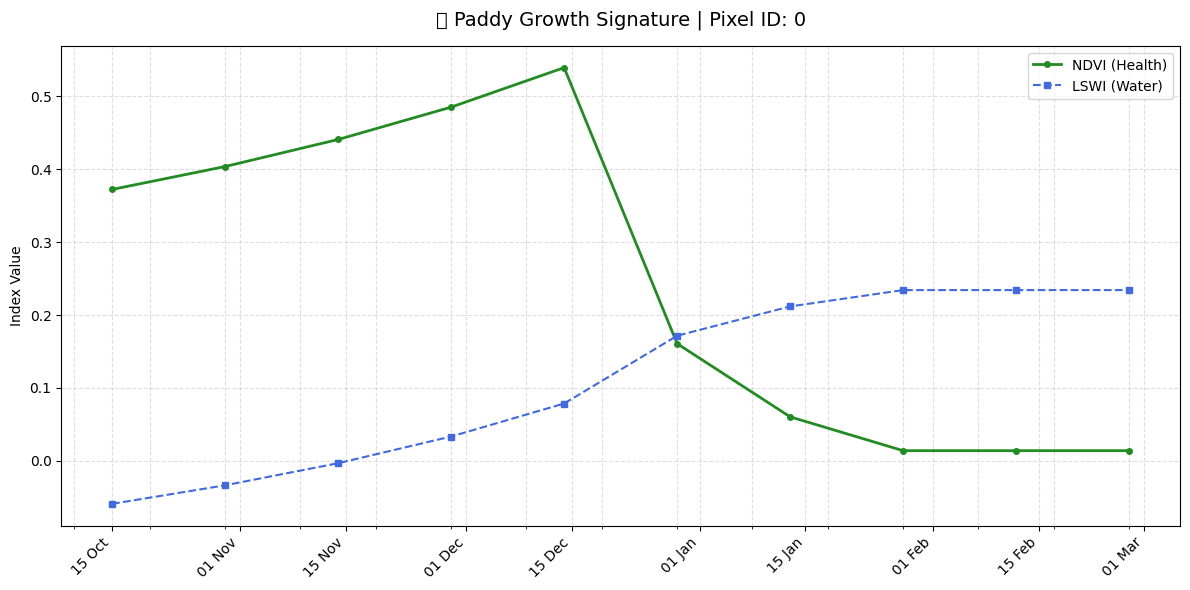

In [163]:
# 1. Filter for your specific pixel
target_pixel = df['pixel_id'].iloc[2]
df_pixel = df[df['pixel_id'] == target_pixel].copy()

# 2. Convert Period to Timestamp for better plotting logic
# This allows Matplotlib to treat the X-axis as a timeline, not just a list of names
df_pixel['plot_date'] = df_pixel['ten_day_start']
df_pixel = df_pixel.sort_values('plot_date')

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_pixel['plot_date'], df_pixel['NDVI_median'], label='NDVI (Health)', 
        marker='o', color='forestgreen', linewidth=2, markersize=4)

ax.plot(df_pixel['plot_date'], df_pixel['LSWI_median'], label='LSWI (Water)', 
        marker='s', color='royalblue', linestyle='--', linewidth=1.5, markersize=4)

# --- CLEAN X-AXIS LOGIC ---
# Format the date to show Day and Month (e.g., "01 Jan")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Automatically find the best interval so labels don't overlap
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# Optional: Add a minor locator for every 10 days to show the composite steps
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=10))

plt.xticks(rotation=45, ha='right') # Slant them for better fitting
plt.title(f"🌾 Paddy Growth Signature | Pixel ID: {target_pixel}", fontsize=14, pad=15)
plt.ylabel("Index Value")
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(frameon=True, loc='best')

plt.tight_layout()
plt.show()

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 63 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   NDVI_median        292280 non-null  float32       
 1   EVI_median         292280 non-null  float32       
 2   EVI2_median        292280 non-null  float32       
 3   LSWI_median        292280 non-null  float32       
 4   NDWI_median        292280 non-null  float32       
 5   GLI_median         292280 non-null  float32       
 6   GCI_median         292280 non-null  float32       
 7   CVI_median         292280 non-null  float32       
 8   SIPI_median        292280 non-null  float32       
 9   RENDVI_median      292280 non-null  float32       
 10  RECI_median        292280 non-null  float32       
 11  CCCI_median        292280 non-null  float32       
 12  S2REP_median       292280 non-null  float32       
 13  BSI_median         292280 non-null  float32 

In [165]:
df['district'].unique()

array(['Puttalam', 'Jaffna', 'Colombo', 'Gampaha', 'Kurunegala',
       'Kalutara', 'Mannar', 'Kilinochchi', 'Galle', 'Anuradhapura',
       'Vavuniya', 'Kegalle', 'Mullaitivu', 'Ratnapura', 'Matara',
       'Kandy', 'Nuwara Eliya', 'Matale', 'Hambantota', 'Trincomalee',
       'Polonnaruwa', 'Monaragala', 'Ampara', 'Badulla', 'Batticaloa'],
      dtype=object)

# Smoothing

In [166]:
# 1. Configuration
# Note: Ensure WINDOW_LENGTH is odd and larger than POLY_ORDER
WINDOW_LENGTH = 5  
POLY_ORDER = 2
# Extract all column names that end with '_median'
target_cols = [col for col in df.columns if col.endswith('_median')]

# Print the list to verify
print("✅ Extracted Target Columns:")
print(target_cols)

# 2. Sort the data to ensure temporal consistency per pixel
# This is crucial so the filter processes time steps in the correct order
df = df.sort_values(by=['pixel_id', 'ten_day_start'])

# 3. Define the smoothing function
def smooth_pixel_wise(group):
    # Only apply filter if the pixel has enough data points to satisfy the window length
    if len(group) >= WINDOW_LENGTH:
        for col in target_cols:
            if col in group.columns:
                # Direct application of Savgol filter (no interpolation needed)
                group[f"{col}_smooth"] = savgol_filter(group[col], WINDOW_LENGTH, POLY_ORDER)
    else:
        # For short sequences, keep raw values to avoid errors
        for col in target_cols:
            if col in group.columns:
                group[f"{col}_smooth"] = group[col]
    return group

# 4. Apply the smoothing per pixel_id
print("⏳ Smoothing 10-day indices per pixel...")
df = df.groupby('pixel_id', group_keys=False).apply(smooth_pixel_wise)

print("✅ Pixel-wise smoothing complete.")
# Preview the new columns
print(df[[col + '_smooth' for col in target_cols]].head())

✅ Extracted Target Columns:
['NDVI_median', 'EVI_median', 'EVI2_median', 'LSWI_median', 'NDWI_median', 'GLI_median', 'GCI_median', 'CVI_median', 'SIPI_median', 'RENDVI_median', 'RECI_median', 'CCCI_median', 'S2REP_median', 'BSI_median', 'NPCRI_median', 'NDSMI_median']
⏳ Smoothing 10-day indices per pixel...
✅ Pixel-wise smoothing complete.
   NDVI_median_smooth  EVI_median_smooth  EVI2_median_smooth  \
0            0.372762           0.262219            0.256750   
1            0.403029           0.269840            0.262947   
2            0.440843           0.277931            0.269449   
3            0.523504           0.285112            0.287936   
4            0.440592           0.293397            0.255858   

   LSWI_median_smooth  NDWI_median_smooth  GLI_median_smooth  \
0           -0.058816            0.221456           0.015020   
1           -0.034450            0.218439           0.028838   
2           -0.003503            0.213517           0.049108   
3            0.03

/tmp/ipykernel_55/2947255909.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pixel_id', group_keys=False).apply(smooth_pixel_wise)


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 0 to 292279
Data columns (total 79 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   NDVI_median           292280 non-null  float32       
 1   EVI_median            292280 non-null  float32       
 2   EVI2_median           292280 non-null  float32       
 3   LSWI_median           292280 non-null  float32       
 4   NDWI_median           292280 non-null  float32       
 5   GLI_median            292280 non-null  float32       
 6   GCI_median            292280 non-null  float32       
 7   CVI_median            292280 non-null  float32       
 8   SIPI_median           292280 non-null  float32       
 9   RENDVI_median         292280 non-null  float32       
 10  RECI_median           292280 non-null  float32       
 11  CCCI_median           292280 non-null  float32       
 12  S2REP_median          292280 non-null  float32       
 13  BSI_

In [168]:
df['district'].unique()

array(['Puttalam', 'Jaffna', 'Colombo', 'Gampaha', 'Kurunegala',
       'Kalutara', 'Mannar', 'Kilinochchi', 'Galle', 'Anuradhapura',
       'Vavuniya', 'Kegalle', 'Mullaitivu', 'Ratnapura', 'Matara',
       'Kandy', 'Nuwara Eliya', 'Matale', 'Hambantota', 'Trincomalee',
       'Polonnaruwa', 'Monaragala', 'Ampara', 'Badulla', 'Batticaloa'],
      dtype=object)

# Velocities

In [169]:
# --- 1. CHRONOLOGICAL SORT ---
# Always sort by pixel and time to ensure .diff() is accurate
df = df.sort_values(['pixel_id', 'ten_day_start'])

# --- 2. CALCULATE VELOCITIES ---
# Use .groupby('pixel_id') but NOT .groupby('year') 
# In inference, we only care about the sequence leading up to 'Now'
df['ndvi_vel'] = df.groupby('pixel_id')['NDVI_median_smooth'].diff().fillna(0)
df['lswi_vel'] = df.groupby('pixel_id')['LSWI_median_smooth'].diff().fillna(0)
df['bsi_vel'] = df.groupby('pixel_id')['BSI_median_smooth'].diff().fillna(0)

# Assign Stage names based on district baselines

In [170]:
import numpy as np
import pandas as pd

def infer_stage_statistically(df, baseline_path='/kaggle/input/datasets/sanilawijesekara/sl-baselines/sri_lanka_district_baselines.csv'):
    print("🧠 Starting Statistical Stage Inference (District-Matched)...")
    
    # 1. Load Baselines
    try:
        baselines = pd.read_csv(baseline_path)
        # Standardize baseline district names to avoid mismatch
        baselines['district'] = baselines['district'].str.strip()
    except FileNotFoundError:
        print(f"❌ Baseline file not found at {baseline_path}!")
        return df

    # 2. Pre-process Inference Data
    # Ensure district names are clean and match the baseline format
    df['district'] = df['district'].str.strip()
    
    # Calculate Velocity (Change in NDVI) for the 2D matching logic
    df['ndvi_vel'] = df.groupby('pixel_id')['NDVI_median_smooth'].diff().fillna(0)
    
    # 3. Identify overlap between Inference districts and Baseline districts
    baseline_districts = baselines['district'].unique()
    print(f"✅ Found {len(baseline_districts)} districts in baseline file.")

    # 4. Define the robust scoring function
    def get_most_likely_stage(row):
        # SKIP LOGIC: If the district is not in our baseline, skip processing
        if row['district'] not in baseline_districts:
            return np.nan
        
        # Filter baselines for this specific district
        dist_base = baselines[baselines['district'] == row['district']]
        
        # Double check for empty dataframe to prevent min() error
        if dist_base.empty:
            return np.nan
        
        scores = {}
        for _, b in dist_base.iterrows():
            # Distance Calculation (Z-score based)
            # We measure how many standard deviations the pixel is from the stage mean
            ndvi_dist = ((row['NDVI_median_smooth'] - b['ndvi_mean']) / b['ndvi_std'])**2
            vel_dist = ((row['ndvi_vel'] - b['vel_median']) / b['vel_std'])**2
            
            # Combine for total statistical distance
            scores[b['stage_name']] = ndvi_dist + vel_dist
        
        # Return the stage name with the smallest distance
        return min(scores, key=scores.get)

    # 5. Apply the function
    df['stage_name'] = df.apply(get_most_likely_stage, axis=1)
    
    # 6. Reporting
    skipped_count = df['stage_name'].isna().sum()
    processed_count = len(df) - skipped_count
    
    print(f"📊 Inference Results:")
    print(f"   - Processed: {processed_count} rows")
    print(f"   - Skipped:   {skipped_count} rows (Districts not in baseline)")
    
    if skipped_count > 0:
        missing = [d for d in df['district'].unique() if d not in baseline_districts]
        print(f"   - Skipped Districts: {missing}")

    print("✅ Statistical inference complete.")
    return df

# Execute
df = infer_stage_statistically(df)

🧠 Starting Statistical Stage Inference (District-Matched)...
✅ Found 25 districts in baseline file.
📊 Inference Results:
   - Processed: 292280 rows
   - Skipped:   0 rows (Districts not in baseline)
✅ Statistical inference complete.


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 292280 entries, 0 to 292279
Data columns (total 83 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   NDVI_median           292280 non-null  float32       
 1   EVI_median            292280 non-null  float32       
 2   EVI2_median           292280 non-null  float32       
 3   LSWI_median           292280 non-null  float32       
 4   NDWI_median           292280 non-null  float32       
 5   GLI_median            292280 non-null  float32       
 6   GCI_median            292280 non-null  float32       
 7   CVI_median            292280 non-null  float32       
 8   SIPI_median           292280 non-null  float32       
 9   RENDVI_median         292280 non-null  float32       
 10  RECI_median           292280 non-null  float32       
 11  CCCI_median           292280 non-null  float32       
 12  S2REP_median          292280 non-null  float32       
 13  BSI_

In [172]:
df['stage_name']

0           Transplant
1           Transplant
2           Vegetative
3           Vegetative
4             Ripening
              ...     
292275      Vegetative
292276    Reproductive
292277    Reproductive
292278    Reproductive
292279    Reproductive
Name: stage_name, Length: 292280, dtype: object

<Axes: >

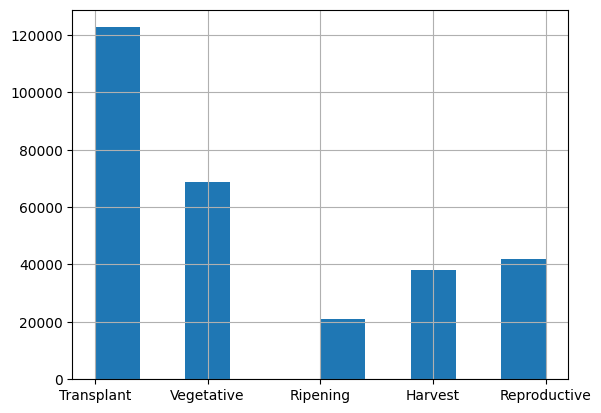

In [173]:
df['stage_name'].hist()

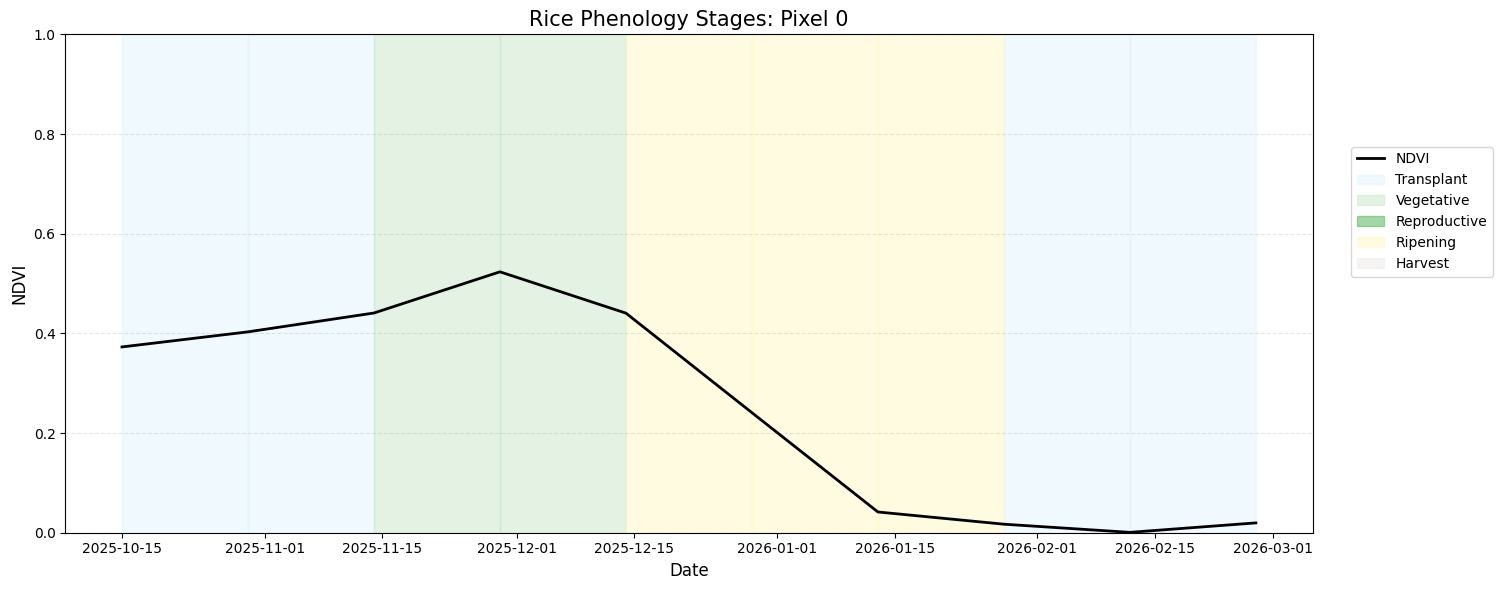

In [174]:
def plot_pixel_stage_progression(df, pixel_id):
    """
    Plots the NDVI curve for a specific pixel and color-codes the background by stage.
    """
    pixel_data = df[df['pixel_id'] == pixel_id].sort_values('ten_day_start')
    
    plt.figure(figsize=(15, 6))
    
    # Define colors for stages
    stage_colors = {
        'Transplant': '#e1f5fe',   # Light Blue
        'Vegetative': '#c8e6c9',   # Light Green
        'Reproductive': '#4caf50', # Dark Green
        'Ripening': '#fff9c4',     # Light Yellow
        'Harvest': '#efebe9'       # Grey/Brown
    }
    
    # 1. Plot the NDVI line
    plt.plot(pixel_data['ten_day_start'], pixel_data['NDVI_median_smooth'], 
             color='black', linewidth=2, label='NDVI (Smoothed)', zorder=5)
    
    # 2. Add colored spans for each stage
    # We find where stages change to create the spans
    pixel_data = pixel_data.reset_index()
    for i in range(len(pixel_data) - 1):
        start_time = pixel_data.loc[i, 'ten_day_start']
        end_time = pixel_data.loc[i+1, 'ten_day_start']
        stage = pixel_data.loc[i, 'stage_name']
        
        plt.axvspan(start_time, end_time, color=stage_colors.get(stage, 'white'), alpha=0.5)

    # 3. Mark the Peak (Reproductive)
    peak_row = pixel_data[pixel_data['stage_name'] == 2]
    if not peak_row.empty:
        max_idx = peak_row['NDVI_median_smooth'].idxmax()
        plt.scatter(pixel_data.loc[max_idx, 'ten_day_start'], 
                    pixel_data.loc[max_idx, 'NDVI_median_smooth'], 
                    color='red', s=100, label='Peak (Reproductive)', zorder=10)

    # Formatting
    plt.title(f"Rice Phenology Stages: Pixel {pixel_id}", fontsize=15)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("NDVI", fontsize=12)
    plt.ylim(0, 1)
    
    # Create custom legend for stages
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='black', lw=2, label='NDVI')]
    for stage, color in stage_colors.items():
        legend_elements.append(plt.Rectangle((0,0),1,1, color=color, label=stage, alpha=0.5))
    
    plt.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(1.15, 0.5))
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_pixel_stage_progression(df, pixel_id=df['pixel_id'].iloc[0])

/tmp/ipykernel_55/1920393558.py:57: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


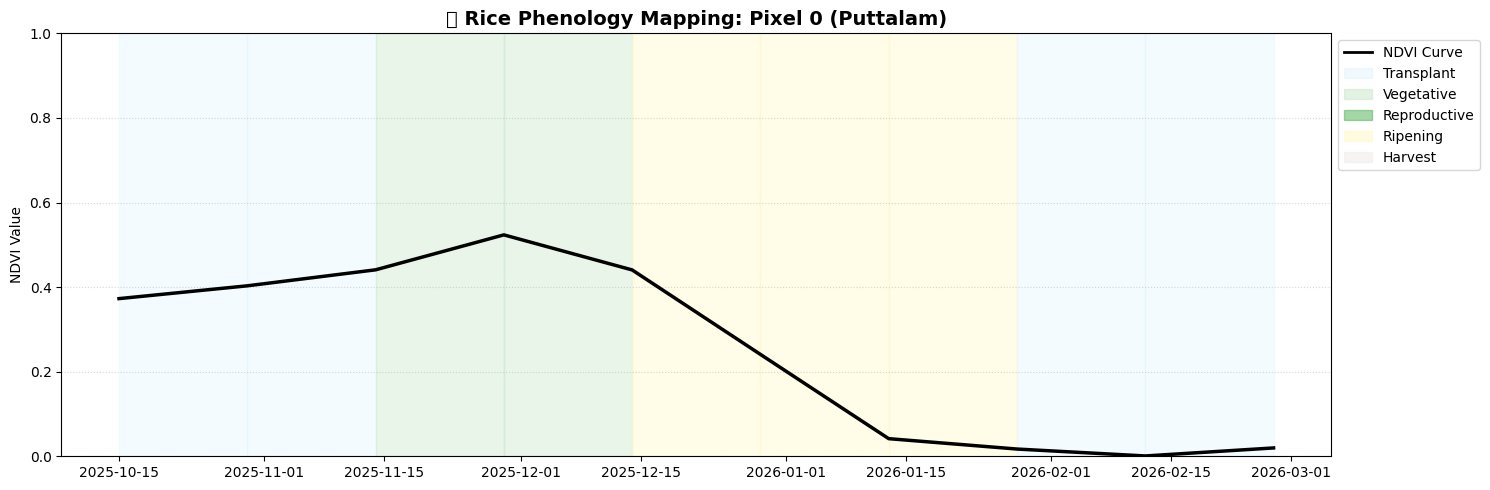

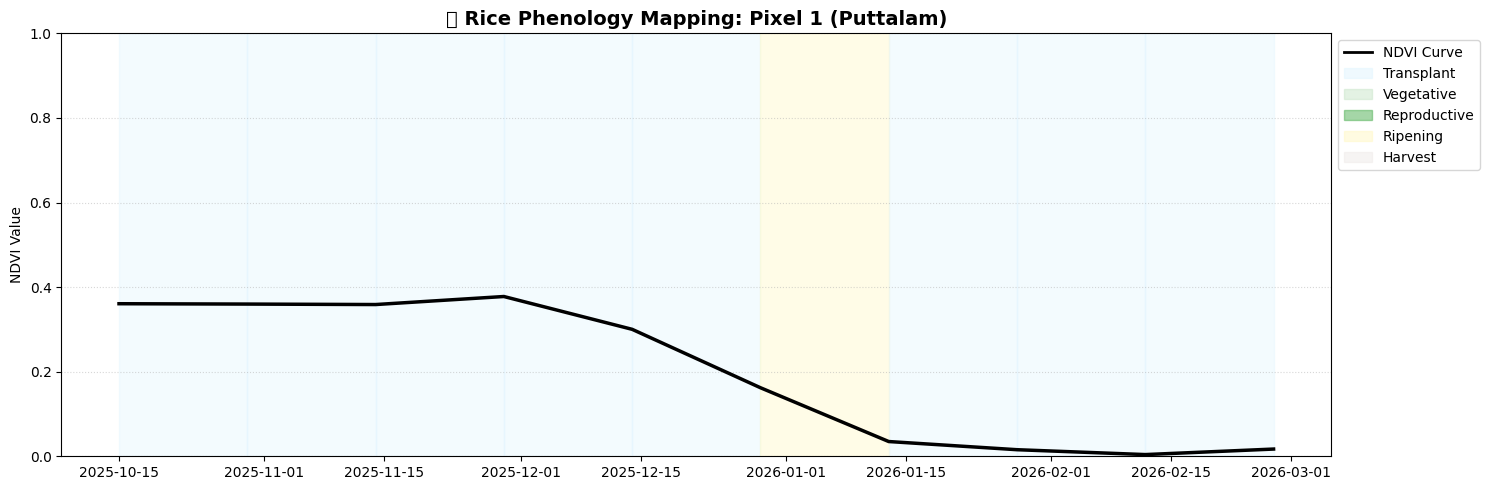

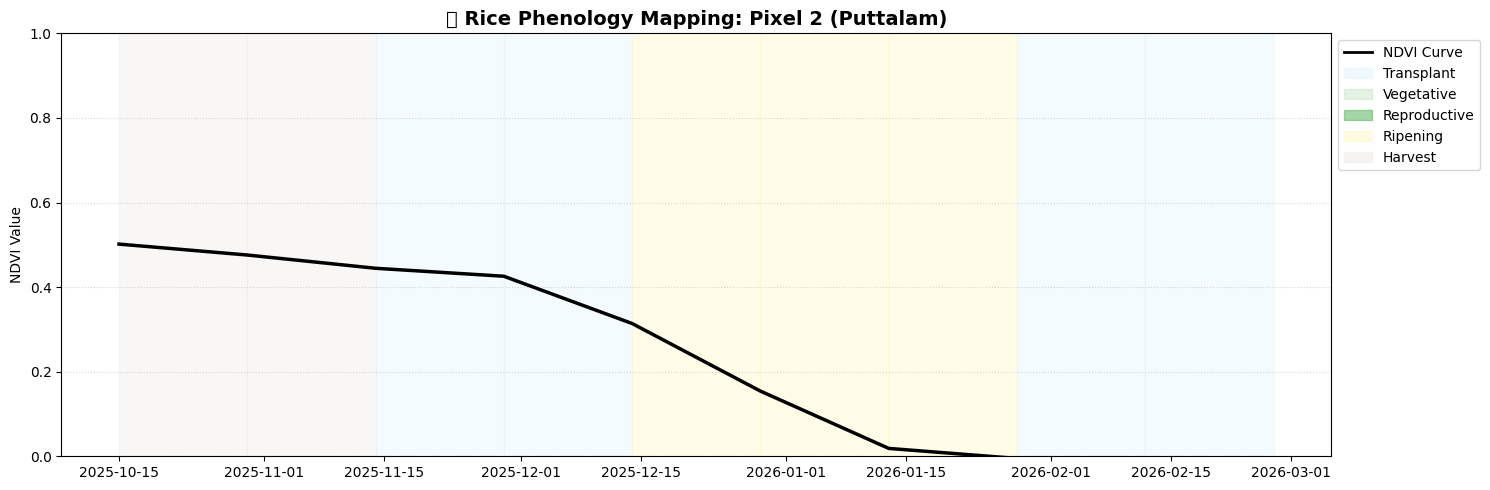

In [175]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_multi_pixel_progression(df, num_pixels=3):
    """
    Selects unique pixels and plots their stage progression.
    """
    # 1. Get unique pixel IDs
    unique_ids = df['pixel_id'].unique()[:num_pixels]
    
    # 2. Define colors for stages (Matching your logic)
    stage_colors = {
        'Transplant': '#e1f5fe',   # Light Blue
        'Vegetative': '#c8e6c9',   # Light Green
        'Reproductive': '#4caf50', # Dark Green
        'Ripening': '#fff9c4',     # Light Yellow
        'Harvest': '#efebe9'       # Grey/Brown
    }

    for pixel_id in unique_ids:
        pixel_data = df[df['pixel_id'] == pixel_id].sort_values('ten_day_start').reset_index(drop=True)
        
        plt.figure(figsize=(15, 5))
        
        # Plot the Smoothed NDVI line
        plt.plot(pixel_data['ten_day_start'], pixel_data['NDVI_median_smooth'], 
                 color='black', linewidth=2.5, label='NDVI (Smoothed)', zorder=5)
        
        # Add background colored spans for each stage
        for i in range(len(pixel_data) - 1):
            start_time = pixel_data.loc[i, 'ten_day_start']
            end_time = pixel_data.loc[i+1, 'ten_day_start']
            stage = pixel_data.loc[i, 'stage_name']
            plt.axvspan(start_time, end_time, color=stage_colors.get(stage, 'white'), alpha=0.4)

        # Mark the actual Peak (Maximum NDVI value during the 'Reproductive' phase)
        repro_phase = pixel_data[pixel_data['stage_name'] == 'Reproductive']
        if not repro_phase.empty:
            peak_idx = repro_phase['NDVI_median_smooth'].idxmax()
            plt.scatter(pixel_data.loc[peak_idx, 'ten_day_start'], 
                        pixel_data.loc[peak_idx, 'NDVI_median_smooth'], 
                        color='red', edgecolor='white', s=120, label='Biological Peak', zorder=10)

        # Styling
        plt.title(f"🌾 Rice Phenology Mapping: Pixel {pixel_id} ({pixel_data['district'].iloc[0]})", 
                  fontsize=14, fontweight='bold')
        plt.ylabel("NDVI Value")
        plt.ylim(0, 1)
        plt.grid(axis='y', linestyle=':', alpha=0.5)

        # Custom Legend
        legend_elements = [Line2D([0], [0], color='black', lw=2, label='NDVI Curve')]
        for stage, color in stage_colors.items():
            legend_elements.append(plt.Rectangle((0,0),1,1, color=color, label=stage, alpha=0.5))
        
        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()

# Run the plot for 3 unique pixels
plot_multi_pixel_progression(df, num_pixels=3)

# ndvi_zscore

In [176]:
baseline_df = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/sl-baselines/sri_lanka_district_baselines.csv")
# Assuming you have already run map_pixels_to_districts and infer_stage_statistically
def add_district_zscore(df, baseline_df):
    # Merge current data with the historical mean/std for that district and stage
    df = df.merge(
        baseline_df[['district', 'stage_name', 'ndvi_mean', 'ndvi_std']], 
        on=['district', 'stage_name'], 
        how='left'
    )
    
    # Formula: (Current Smoothed NDVI - Historical Mean) / Historical Std
    df['ndvi_zscore'] = (df['NDVI_median_smooth'] - df['ndvi_mean']) / df['ndvi_std']
    
    # Optional: Fill missing values (if a district/stage combo is missing) and clip outliers
    df['ndvi_zscore'] = df['ndvi_zscore'].fillna(0).clip(-3, 3)
    
    return df
df = add_district_zscore(df, baseline_df)

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 86 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   NDVI_median           292280 non-null  float32       
 1   EVI_median            292280 non-null  float32       
 2   EVI2_median           292280 non-null  float32       
 3   LSWI_median           292280 non-null  float32       
 4   NDWI_median           292280 non-null  float32       
 5   GLI_median            292280 non-null  float32       
 6   GCI_median            292280 non-null  float32       
 7   CVI_median            292280 non-null  float32       
 8   SIPI_median           292280 non-null  float32       
 9   RENDVI_median         292280 non-null  float32       
 10  RECI_median           292280 non-null  float32       
 11  CCCI_median           292280 non-null  float32       
 12  S2REP_median          292280 non-null  float32       
 13 

In [178]:
df['ndvi_zscore']

0        -0.141105
1         0.137842
2        -0.857940
3        -0.211524
4        -0.483285
            ...   
292275    1.158136
292276    0.533931
292277    0.808706
292278    0.915171
292279    0.841741
Name: ndvi_zscore, Length: 292280, dtype: float64

<Axes: >

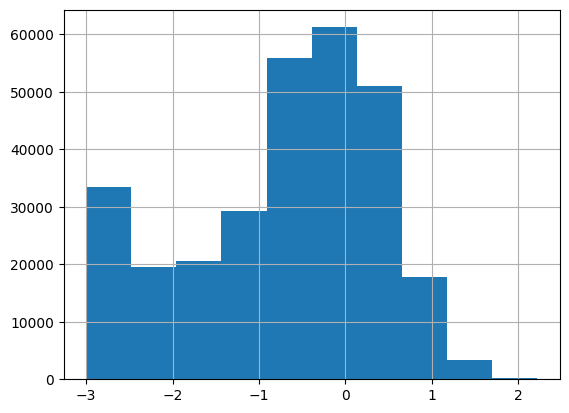

In [179]:
df['ndvi_zscore'].hist()

# Z-score Velocities and cpi

In [180]:
# Step B: Get Cohort Health (Your CPI Logic)
if df['pixel_id'].nunique() > 10:
    # We use a safety wrapper for the robust Z to handle tiny groups
    def safe_robust_z(x):
        if len(x) < 5: return np.zeros(len(x)) # Not enough peers for a cohort
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        denom = max(iqr, 0.05) 
        return (x - x.median()) / denom

    groups = df.groupby(['ten_day_start', 'stage_name'])
    
    df['ndvi_vel_z'] = groups['ndvi_vel'].transform(safe_robust_z)
    df['bsi_z'] = groups['BSI_median_smooth'].transform(safe_robust_z)
    df['lswi_vel_z'] = groups['lswi_vel'].transform(safe_robust_z)

    # Calculate CPI
    df['cpi'] = (
        (df['ndvi_vel_z'] * -1.0) + 
        (df['bsi_z'] * 0.8) + 
        (df['lswi_vel_z'] * -0.6)
    )
else:
    # Single-pixel or small batch mode
    df['cpi'] = 0
    df['ndvi_vel_z'] = 0 
    # Note: ndvi_zscore still works because it's based on the CSV!

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 90 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   NDVI_median           292280 non-null  float32       
 1   EVI_median            292280 non-null  float32       
 2   EVI2_median           292280 non-null  float32       
 3   LSWI_median           292280 non-null  float32       
 4   NDWI_median           292280 non-null  float32       
 5   GLI_median            292280 non-null  float32       
 6   GCI_median            292280 non-null  float32       
 7   CVI_median            292280 non-null  float32       
 8   SIPI_median           292280 non-null  float32       
 9   RENDVI_median         292280 non-null  float32       
 10  RECI_median           292280 non-null  float32       
 11  CCCI_median           292280 non-null  float32       
 12  S2REP_median          292280 non-null  float32       
 13 

/tmp/ipykernel_55/4257102453.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='stage_name', order=present_stages, palette='magma')


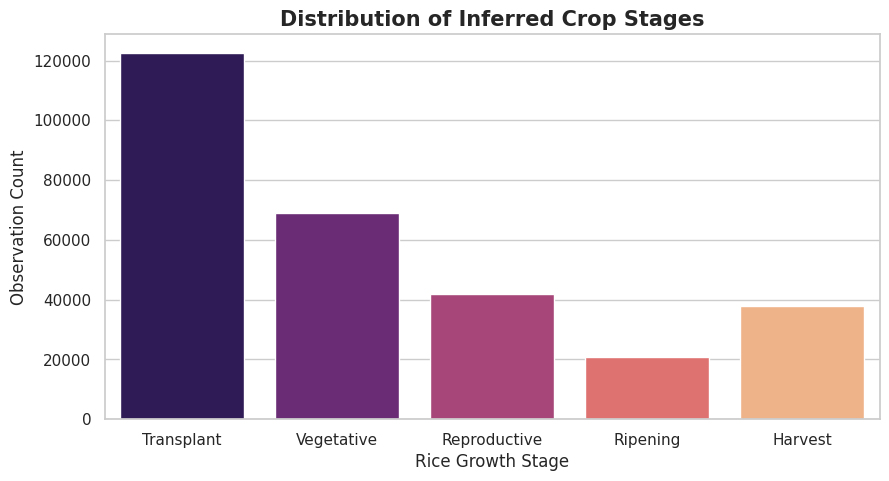

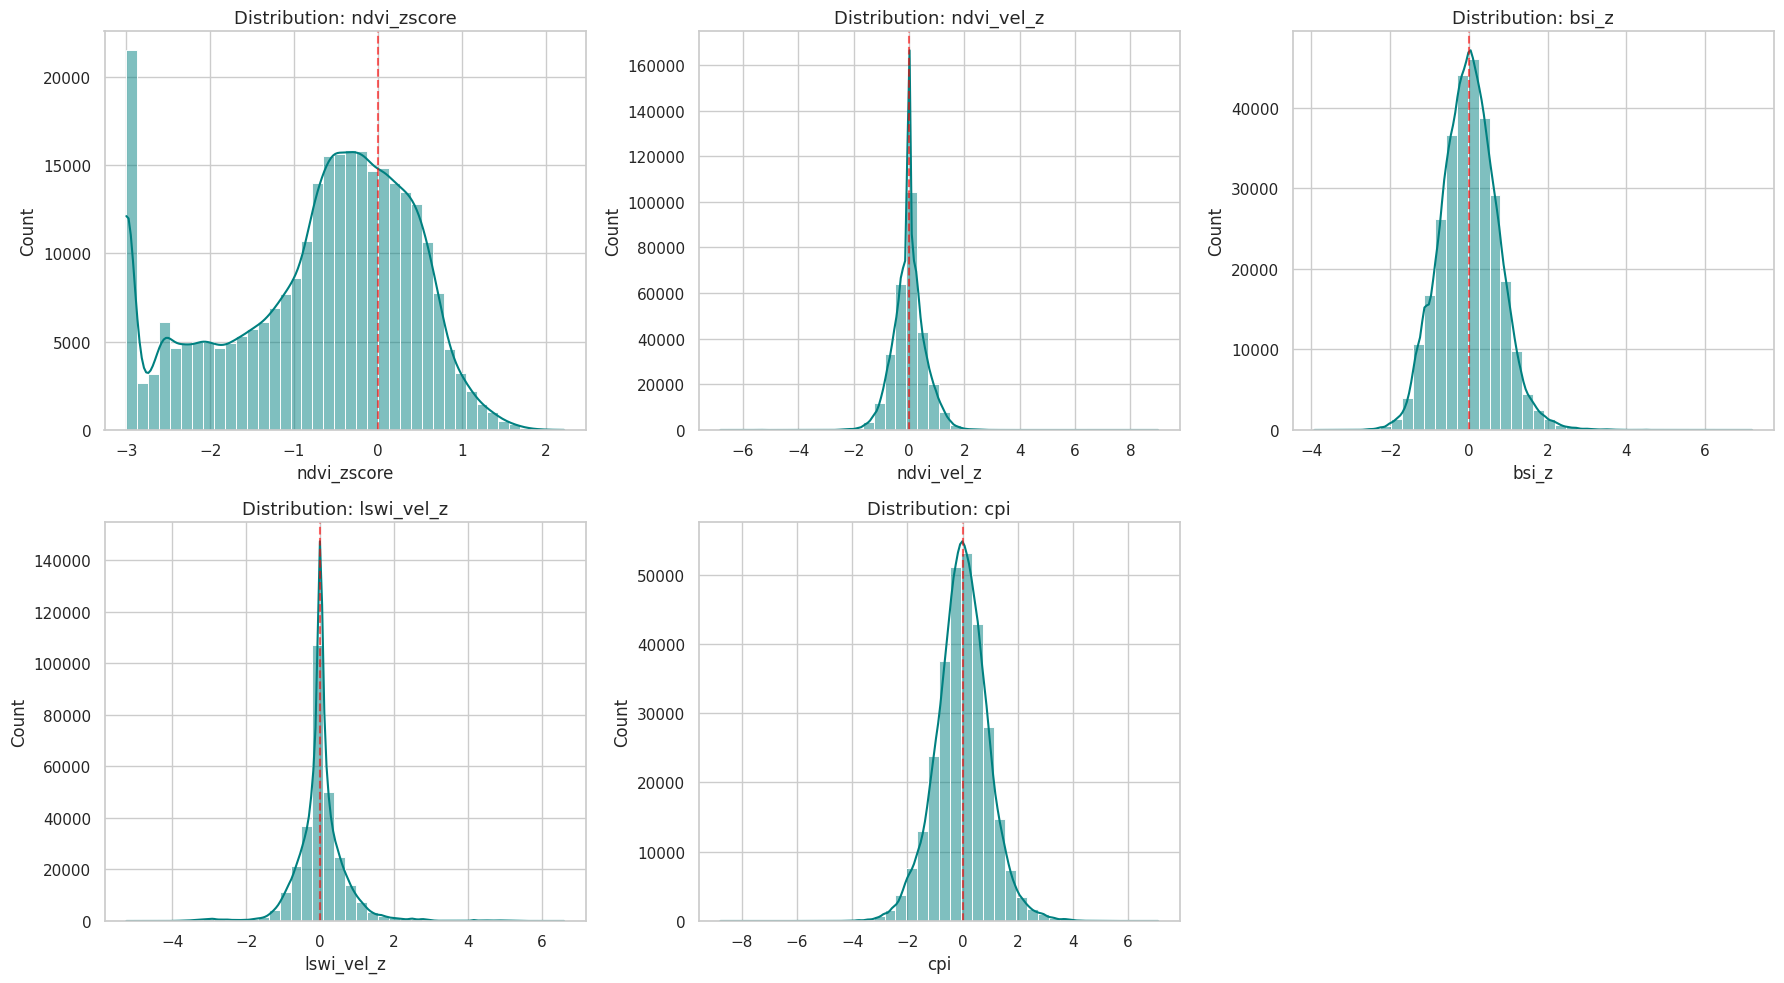

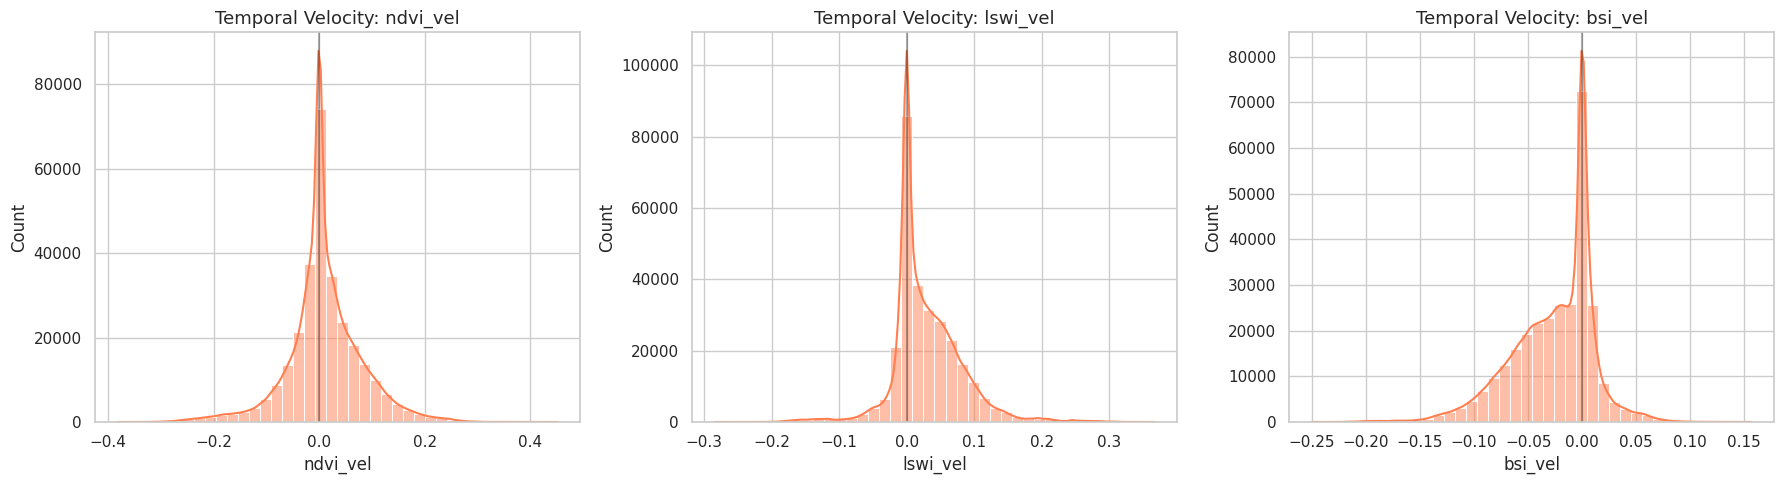

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_inference_distributions(df):
    # Set visual theme
    sns.set_theme(style="whitegrid")
    
    # --- 1. Growth Stage Distribution ---
    plt.figure(figsize=(10, 5))
    # Order them chronologically for the plot
    stage_order = ['Transplant', 'Vegetative', 'Reproductive', 'Ripening', 'Harvest']
    present_stages = [s for s in stage_order if s in df['stage_name'].unique()]
    
    sns.countplot(data=df, x='stage_name', order=present_stages, palette='magma')
    plt.title('Distribution of Inferred Crop Stages', fontsize=15, fontweight='bold')
    plt.xlabel('Rice Growth Stage')
    plt.ylabel('Observation Count')
    plt.show()

    # --- 2. Health & Stress Indicators (Z-Scores & CPI) ---
    # These should ideally look like Bell Curves centered near 0
    health_features = ['ndvi_zscore', 'ndvi_vel_z', 'bsi_z', 'lswi_vel_z', 'cpi']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(health_features):
        sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=40)
        axes[i].set_title(f'Distribution: {col}', fontsize=13)
        axes[i].axvline(0, color='red', linestyle='--', alpha=0.6) # Reference line at 0
        
    # Remove the empty 6th subplot
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

    # --- 3. Momentum Features (Velocities) ---
    vel_features = ['ndvi_vel', 'lswi_vel', 'bsi_vel']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, col in enumerate(vel_features):
        sns.histplot(df[col], kde=True, ax=axes[i], color='coral', bins=40)
        axes[i].set_title(f'Temporal Velocity: {col}', fontsize=13)
        axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
        
    plt.tight_layout()
    plt.show()

# Execute the plotting
plot_inference_distributions(df)

In [183]:
df.head()

,NDVI_median,EVI_median,EVI2_median,LSWI_median,NDWI_median,GLI_median,GCI_median,CVI_median,SIPI_median,RENDVI_median,...,lswi_vel,bsi_vel,stage_name,ndvi_mean,ndvi_std,ndvi_zscore,ndvi_vel_z,bsi_z,lswi_vel_z,cpi
0,0.372363,0.262211,0.256746,-0.059184,0.221631,0.014513,1.594723,3.078861,1.305787,0.170191,...,0.000000,0.000000,Transplant,0.388073,0.108505,-0.141105,0.000000,-0.195791,0.000000,-0.156633
1,0.403806,0.269856,0.262955,-0.033735,0.218106,0.029811,1.702091,3.100575,1.264353,0.188717,...,0.024366,-0.020024,Transplant,0.388073,0.108505,0.137842,0.829051,0.200947,-0.256543,-0.514367
2,0.440906,0.277931,0.269449,-0.003442,0.213467,0.049230,1.833877,3.115745,1.223062,0.209897,...,0.030947,-0.026757,Vegetative,0.550553,0.127876,-0.857940,-0.732311,0.497894,-0.878348,1.657635
3,0.485343,0.286474,0.276248,0.033227,0.207090,0.074694,1.999474,3.116863,1.181916,0.234345,...,0.033572,-0.029782,Vegetative,0.550553,0.127876,-0.211524,-0.089156,1.039907,-0.869140,1.442566
4,0.539531,0.295526,0.283373,0.078519,0.197770,0.109549,2.213812,3.088643,1.140912,0.262881,...,0.060417,-0.056620,Ripening,0.499797,0.122506,-0.483285,-0.362315,1.541075,0.526475,1.279291


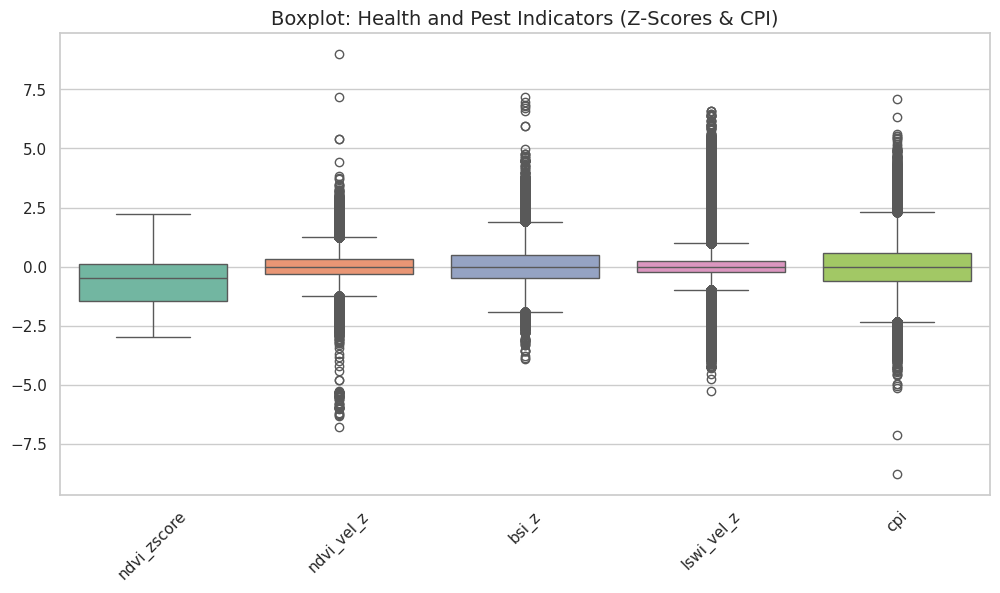

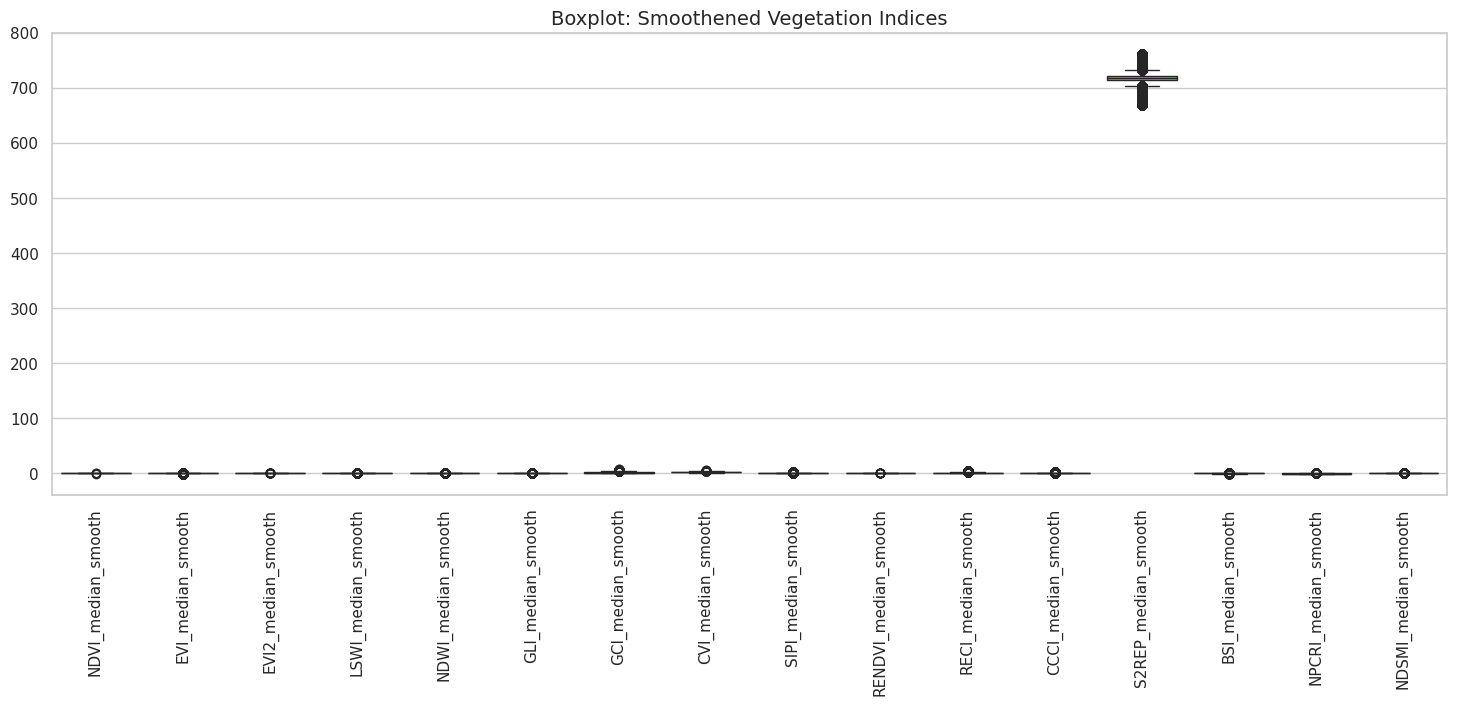

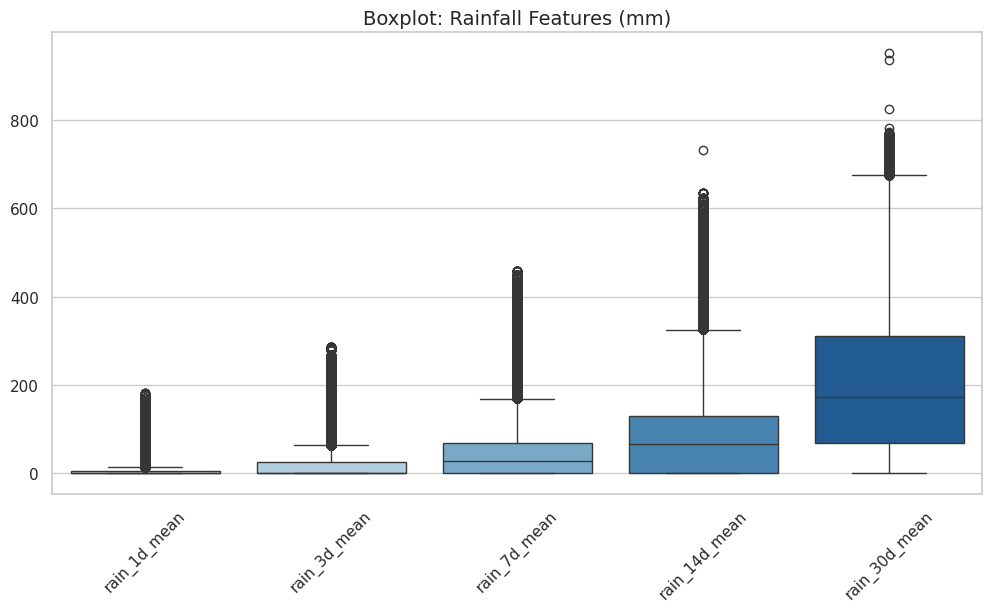

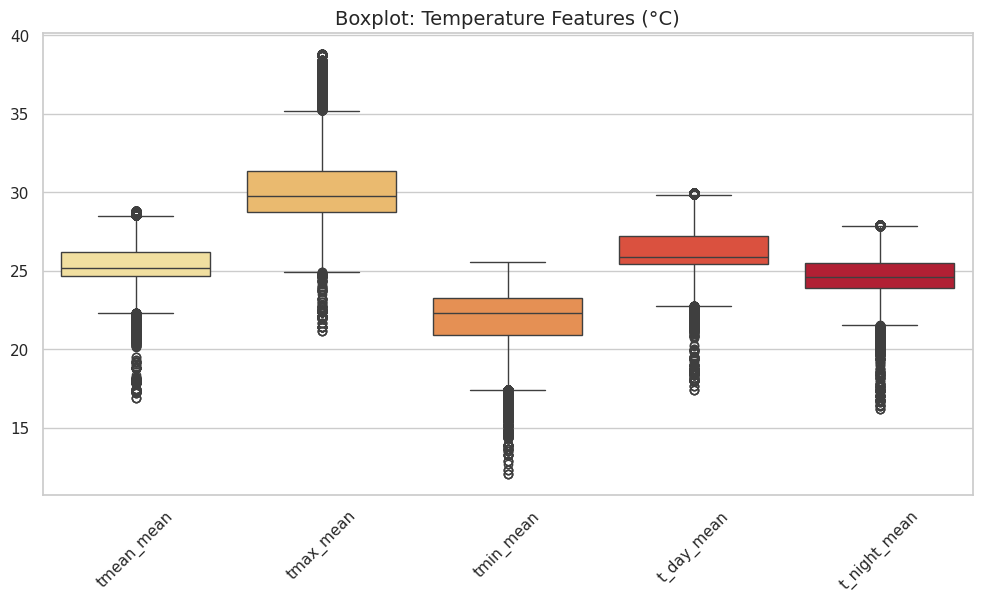

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_boxplots(df):
    sns.set_theme(style="whitegrid")
    
    # Define feature groups
    health_cols = ['ndvi_zscore', 'ndvi_vel_z', 'bsi_z', 'lswi_vel_z', 'cpi']
    
    smooth_cols = [col for col in df.columns if col.endswith('_smooth')]
    
    weather_rain = [col for col in df.columns if 'rain' in col]
    weather_temp = [col for col in df.columns if col.startswith('t') and 'mean' in col and 'rain' not in col]

    # --- Plot 1: Health & Stress Indices ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[health_cols], palette="Set2")
    plt.title("Boxplot: Health and Pest Indicators (Z-Scores & CPI)", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

    # --- Plot 2: Smoothened Vegetation Indices ---
    plt.figure(figsize=(18, 6))
    sns.boxplot(data=df[smooth_cols], palette="viridis")
    plt.title("Boxplot: Smoothened Vegetation Indices", fontsize=14)
    plt.xticks(rotation=90)
    plt.show()

    # --- Plot 3: Weather Features (Rainfall) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[weather_rain], palette="Blues")
    plt.title("Boxplot: Rainfall Features (mm)", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

    # --- Plot 4: Weather Features (Temperature) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[weather_temp], palette="YlOrRd")
    plt.title("Boxplot: Temperature Features (°C)", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# Run the plotting function
plot_feature_boxplots(df)

⚠️ Warning: Significant bias detected in the following districts/stages:
         district    stage_name  ndvi_zscore
40         Jaffna    Transplant    -2.312649
60    Kilinochchi    Transplant    -2.274715
39         Jaffna      Ripening    -2.138867
8    Anuradhapura    Transplant    -2.087222
59    Kilinochchi      Ripening    -2.075051
..            ...           ...          ...
102      Puttalam       Harvest    -0.306200
24          Galle      Ripening    -0.305058
43       Kalutara  Reproductive     0.302163
14     Batticaloa      Ripening     0.320166
11        Badulla  Reproductive     0.475321

[62 rows x 3 columns]


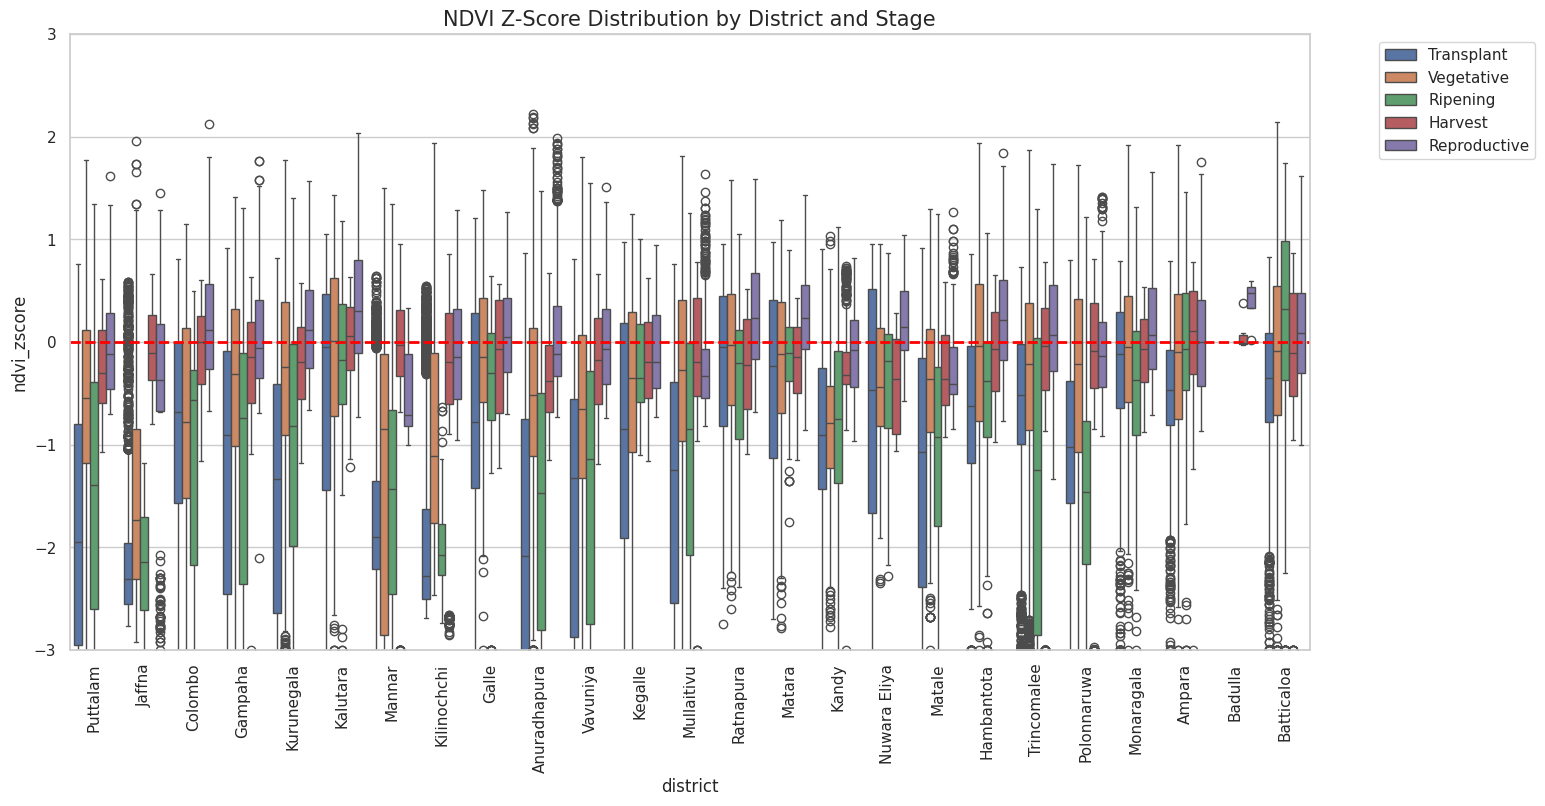

In [185]:
def check_district_bias(df):
    # Calculate median z-score per district and stage
    bias_report = df.groupby(['district', 'stage_name'])['ndvi_zscore'].median().reset_index()
    
    # Identify "Strong Bias" (where median is > 0.3 or < -0.3)
    # A perfect baseline should result in a median of 0.0
    strong_bias = bias_report[bias_report['ndvi_zscore'].abs() > 0.3].sort_values(by='ndvi_zscore')
    
    if strong_bias.empty:
        print("✅ No significant district bias detected. Baselines are well-calibrated.")
    else:
        print("⚠️ Warning: Significant bias detected in the following districts/stages:")
        print(strong_bias)
        
    # Visual check using a FacetGrid Boxplot
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(16, 8))
    sns.boxplot(data=df, x='district', y='ndvi_zscore', hue='stage_name')
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.title("NDVI Z-Score Distribution by District and Stage", fontsize=15)
    plt.xticks(rotation=90)
    plt.ylim(-3, 3) # Zoom in on the core distribution
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
    
    return bias_report

bias_df = check_district_bias(df)

# AssignSeason

In [186]:
# 2. Extract the month
df['month'] = df['ten_day_start'].dt.month

# 3. Define the season logic
# If month is between 4 (April) and 8 (August), it's Yala. Otherwise, it's Maha.
df['season'] = np.where(df['month'].isin([4, 5, 6, 7, 8]), 'Yala', 'Maha')

# Example check:
# A date like '2022-01-15' has month 1, which will be assigned 'Maha'
print(df[['ten_day_start', 'month', 'season']].head())

  ten_day_start  month season
0    2025-10-15     10   Maha
1    2025-10-30     10   Maha
2    2025-11-14     11   Maha
3    2025-11-29     11   Maha
4    2025-12-14     12   Maha


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 91 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   NDVI_median           292280 non-null  float32       
 1   EVI_median            292280 non-null  float32       
 2   EVI2_median           292280 non-null  float32       
 3   LSWI_median           292280 non-null  float32       
 4   NDWI_median           292280 non-null  float32       
 5   GLI_median            292280 non-null  float32       
 6   GCI_median            292280 non-null  float32       
 7   CVI_median            292280 non-null  float32       
 8   SIPI_median           292280 non-null  float32       
 9   RENDVI_median         292280 non-null  float32       
 10  RECI_median           292280 non-null  float32       
 11  CCCI_median           292280 non-null  float32       
 12  S2REP_median          292280 non-null  float32       
 13 

<Axes: >

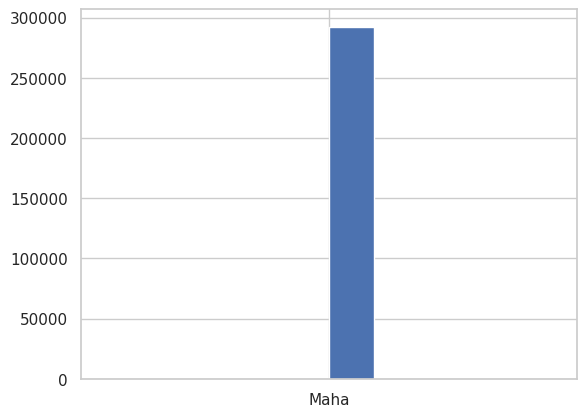

In [188]:
df['season'].hist()

# Remove unnecessary columns

In [189]:
import pandas as pd
import numpy as np

# 1. Define the target columns (Now including the 6 Hazards)
target_cols = [
    'pixel_id', 'year', 'date', 'rain_1d_mean', 'rain_3d_mean', 'rain_7d_mean', 
    'rain_14d_mean', 'rain_30d_mean', 'tmean_mean', 'tmax_mean', 'tmin_mean', 
    't_day_mean', 't_night_mean', 'rh_mean_mean', 'lat', 'lon', 'elevation', 
    'slope', 'ten_day_start', 'delta_days', 'doy', 'doy_sin', 'doy_cos', 
    'ndvi_median_smooth', 'evi_median_smooth', 'evi2_median_smooth', 
    'lswi_median_smooth', 'ndwi_median_smooth', 'gli_median_smooth', 
    'gci_median_smooth', 'cvi_median_smooth', 'sipi_median_smooth', 
    'rendvi_median_smooth', 'reci_median_smooth', 'ccci_median_smooth', 
    's2rep_median_smooth', 'bsi_median_smooth', 'npcri_median_smooth', 
    'ndsmi_median_smooth', 'stage_name', 'ndvi_zscore', 'ndvi_vel', 
    'lswi_vel', 'bsi_vel', 'ndvi_vel_z', 'bsi_z', 'lswi_vel_z', 'cpi', 
    'month', 'season', 'district',
    # --- ADDED HAZARDS ---
    'hazard_flood', 'hazard_drought', 'hazard_heavy_rain', 
    'hazard_landslide', 'hazard_lightning', 'hazard_wind'
]

# 2. Standardize column names to lowercase
# This ensures hazard_FLOOD becomes hazard_flood to match our list
df.columns = [col.lower() for col in df.columns]

# 3. Filter for existing columns only
# This prevents errors if one specific hazard wasn't present in the source
existing_target_cols = [col for col in target_cols if col in df.columns]
df = df[existing_target_cols].copy()

# 4. Map 'stage_name' to integers (The 'stage' column)
stage_mapping = {
    'Transplant': 0, 
    'Vegetative': 1, 
    'Reproductive': 2, 
    'Ripening': 3, 
    'Harvest': 4
}
if 'stage_name' in df.columns:
    df['stage'] = df['stage_name'].map(stage_mapping)

# 5. Ensure Hazards are int64 (for model compatibility)
hazard_list = ['hazard_flood', 'hazard_drought', 'hazard_heavy_rain', 
               'hazard_landslide', 'hazard_lightning', 'hazard_wind']

for h_col in hazard_list:
    if h_col in df.columns:
        df[h_col] = df[h_col].fillna(0).astype('int64')

# Check results
print("✅ Final Dataset Columns Ready for BiLSTM Inference:")
print(df.info())

✅ Final Dataset Columns Ready for BiLSTM Inference:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 58 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   pixel_id              292280 non-null  int64         
 1   year                  292280 non-null  int32         
 2   date                  292280 non-null  datetime64[ns]
 3   rain_1d_mean          292280 non-null  float64       
 4   rain_3d_mean          292280 non-null  float64       
 5   rain_7d_mean          292280 non-null  float64       
 6   rain_14d_mean         292280 non-null  float64       
 7   rain_30d_mean         292280 non-null  float64       
 8   tmean_mean            292280 non-null  float64       
 9   tmax_mean             292280 non-null  float64       
 10  tmin_mean             292280 non-null  float64       
 11  t_day_mean            292280 non-null  float64       
 12  t_nigh

# District id, season id, cycle id

In [190]:
import joblib
le = joblib.load("/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/district_encoder.joblib")
# 1. Standardize spelling to match the LabelEncoder classes
# We change 'Kalutara' -> 'Kaluthara' and 'Nuwara-Eliya' -> 'Nuwara Eliya' if needed
spelling_fixes = {
    'Kalutara': 'Kaluthara',
    'kalutara': 'Kaluthara',
    'Kaluthara ': 'Kaluthara' # In case of trailing spaces
}

df['district'] = df['district'].replace(spelling_fixes)

# 2. Safety Step: Strip any accidental whitespace
df['district'] = df['district'].str.strip()

# 3. Now perform the transformation
try:
    df['district_id'] = le.transform(df['district'])
    print("✅ District encoding successful!")
except ValueError as e:
    # If it still fails, this will tell us exactly which name is the problem
    print(f"❌ Still missing a label: {e}")
# Vectorized Season/Cycle Logic
cond_yala = (df['month'] >= 5) & (df['month'] <= 8)
cond_maha_p2 = (df['month'] <= 3)

df['season_id'] = np.where(cond_yala, 1, 0) # Yala=1, Maha=0
df['cycle_id'] = np.select(
    [cond_yala, cond_maha_p2],
    [df['year'].astype(str) + '_Yala', (df['year']-1).astype(str) + '_' + df['year'].astype(str) + '_Maha'],
    default=df['year'].astype(str) + '_' + (df['year']+1).astype(str) + '_Maha'
)
print("season encoding successsful")

✅ District encoding successful!
season encoding successsful


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 61 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   pixel_id              292280 non-null  int64         
 1   year                  292280 non-null  int32         
 2   date                  292280 non-null  datetime64[ns]
 3   rain_1d_mean          292280 non-null  float64       
 4   rain_3d_mean          292280 non-null  float64       
 5   rain_7d_mean          292280 non-null  float64       
 6   rain_14d_mean         292280 non-null  float64       
 7   rain_30d_mean         292280 non-null  float64       
 8   tmean_mean            292280 non-null  float64       
 9   tmax_mean             292280 non-null  float64       
 10  tmin_mean             292280 non-null  float64       
 11  t_day_mean            292280 non-null  float64       
 12  t_night_mean          292280 non-null  float64       
 13 

# Saving the pipeline 1 dataframe

In [192]:
df.to_csv("inference_p1.csv", index=False)

In [193]:
print("saved successfully")

saved successfully
